# NB3 -- Cross-Species Convergence Testing

**FunPan Aspergillus Pangenome Project -- Results 3.3**

This notebook tests whether phenotype-associated genomic features are **convergent** across species --
i.e., whether the same orthogroups, functional terms, or BGC/GCF families are independently significant
in multiple species with the same phenotypic contrast.

**Sections:**
1. Configuration & Data Loading (combined OrthoFinder, phenotypes, per-species pan-GWAS results)
2. Map Species OGs to Combined Pangenome
3. Pathogenic Convergence (A. fumigatus vs A. flavus)
4. Industrial Convergence (A. niger vs A. oryzae)
5. Multi-Layer Convergence Test (OG PAV, functional terms, BGC/GCF)
6. Null Model (Permutation Test)
7. CAZy, Protease, Secretome Cross-Species Comparisons

**Inputs:** NB0_Results (phenotype tables), NB1_Results (PAV/CNV matrices, OG consensus), NB2_Results (pan-GWAS results)
**Outputs:** NB3_Results/

---
## Section 1: Configuration & Data Loading

In [1]:
import os, sys, warnings, glob, re
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import fisher_exact, hypergeom
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

sys.path.insert(0, '/datadrive/Analysis')
import funpan_utils as fpu
import funpan_convergence as fpc

print('Modules loaded successfully.')

Modules loaded successfully.


In [2]:
# --- Paths ---
BASE_DIR = Path('/datadrive')
ANALYSIS_DIR = BASE_DIR / 'Analysis'
SPECIES_ROOT = BASE_DIR / 'Species' / 'Aspergillus'

NB0_RESULTS = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS = ANALYSIS_DIR / 'NB2_Results'
NB3_RESULTS = ANALYSIS_DIR / 'NB3_Results'

# Combined OrthoFinder results
COMBINED_OF_DIR = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_OG_GENECOUNT = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.tsv'

# Species list
SPECIES_LIST = fpu.SPECIES_LIST  # ['fumigatus', 'flavus', 'niger', 'oryzae']
FDR_THRESHOLD = 0.1

# Create output directories
NB3_RESULTS.mkdir(parents=True, exist_ok=True)
(NB3_RESULTS / 'convergence').mkdir(parents=True, exist_ok=True)

print(f'Species: {SPECIES_LIST}')
print(f'Combined OrthoFinder: {COMBINED_OF_DIR}')
print(f'Output: {NB3_RESULTS}')

Species: ['fumigatus', 'flavus', 'niger', 'oryzae']
Combined OrthoFinder: /datadrive/Species/Aspergillus/all_combined/orthofinder_output/Results_Apr08
Output: /datadrive/Analysis/NB3_Results


In [3]:
# --- Load combined OrthoFinder results ---
print('Loading combined OrthoFinder gene count matrix...')
combined_genecount = fpc.load_combined_orthogroups_genecount(str(COMBINED_OG_GENECOUNT))
print(f'  Gene count matrix: {combined_genecount.shape}')

print('\nLoading combined OrthoFinder long format...')
combined_og_long = fpc.load_combined_orthogroups_long(str(COMBINED_OG_TSV))
print(f'  Long format: {combined_og_long.shape}')
print(f'  Unique orthogroups: {combined_og_long["Orthogroup"].nunique()}')
print(f'  Unique species: {combined_og_long["Species"].nunique()}')
print(f'  Species represented: {sorted(combined_og_long["Species"].unique())}')

# Build genome-species mapping
genome_mapping = fpc.build_genome_species_mapping(combined_genecount)
print(f'\nGenome-species mapping: {len(genome_mapping)} genomes')
for sp in SPECIES_LIST:
    n = sum(1 for v in genome_mapping.values() if v == sp)
    print(f'  {sp}: {n} genomes')

Loading combined OrthoFinder gene count matrix...
  Gene count matrix: (15163, 212)

Loading combined OrthoFinder long format...
  Long format: (2328114, 4)
  Unique orthogroups: 15163
  Unique species: 4
  Species represented: ['flavus', 'fumigatus', 'niger', 'oryzae']

Genome-species mapping: 211 genomes
  fumigatus: 89 genomes
  flavus: 70 genomes
  niger: 19 genomes
  oryzae: 33 genomes


In [4]:
# --- Load phenotype classifications from NB0 ---
pheno_classified = pd.read_csv(NB0_RESULTS / 'phenotype_classified_for_gwas.csv')
print(f'Phenotype classification table: {pheno_classified.shape}')
print(f'Columns: {list(pheno_classified.columns)}')
display(pheno_classified.head())

Phenotype classification table: (207, 69)
Columns: ['Assembly Accession', 'Assembly Name', 'Organism Name', 'Organism Taxonomic ID', 'ANI Check status', 'Organism Infraspecific Names Breed', 'Organism Infraspecific Names Strain', 'Organism Infraspecific Names Cultivar', 'Organism Infraspecific Names Ecotype', 'Organism Infraspecific Names Isolate', 'Organism Infraspecific Names Sex', 'Annotation Name', 'total_len', 'Assembly Stats Total Number of Chromosomes', 'Assembly Level', 'Assembly Type', 'Assembly Release Date', 'WGS project accession', 'n50', 'Assembly Stats Scaffold N50', 'Assembly Stats Number of Scaffolds', 'contigs', 'busco', 'BUSCO Fragmented', 'BUSCO Missing', 'busco_total', 'BUSCO Single Copy', 'BUSCO Duplicated', 'BUSCO Lineage', 'Assembly Sequencing Tech', 'Assembly Submitter', 'Assembly BioProject Accession', 'Assembly BioSample Accession', 'Annotation Count Gene Total', 'Annotation Count Gene Protein-coding', 'Annotation Count Gene Pseudogene', 'Type Material Display

,Assembly Accession,Assembly Name,Organism Name,Organism Taxonomic ID,ANI Check status,Organism Infraspecific Names Breed,Organism Infraspecific Names Strain,Organism Infraspecific Names Cultivar,Organism Infraspecific Names Ecotype,Organism Infraspecific Names Isolate,...,PhenotypeScores,PhenotypeMatched,FieldProvenance,NegationsApplied,IsolationClass,IsolationSubclass,IsolationSubtype,ClassConfidence,ClassificationConfidence,UsageClass
0,GCA_000150145.1,ASM15014v1,Aspergillus fumigatus A1163,451804,NaN,NaN,A1163,NaN,NaN,NaN,...,"{""Human-pathogenic"": 10.0, ""Animal-pathogenic""...","{""Human-pathogenic"": [""Established strain: Asp...","{""Provenance:Clinical"": [""description"", ""comme...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
1,GCA_001599455.1,JCM_10253_assembly_v001,Aspergillus fumigatus var. fumigatus,41122,NaN,NaN,JCM 10253,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""description"", ""...",[],Environmental,Environmental,Environmental,low,low,Wild-type
2,GCA_001715275.2,ASM171527v2,Aspergillus fumigatus,746128,NaN,NaN,LMB-35Aa,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""isolation_sourc...",[],Environmental,Environmental,Environmental,low,low,Wild-type
3,GCA_015572005.1,ASM1557200v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA A,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
4,GCA_015572015.1,ASM1557201v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA B,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic


In [5]:
# --- Load per-species pan-GWAS results from NB2 ---
species_gwas = fpc.load_gwas_results_from_nb2(SPECIES_LIST, NB2_RESULTS)

fumigatus: loaded 10 result files
  bgc_pav_assoc_environmental_vs_rest: 0 features, 0 significant
  bgc_pav_assoc_human_pathogenic_vs_rest: 0 features, 0 significant
  cnv_assoc_environmental_vs_rest: 1876 features, 87 significant
  cnv_assoc_human_pathogenic_vs_rest: 1876 features, 87 significant
  gcf_cnv_assoc_environmental_vs_rest: 34 features, 3 significant
  gcf_cnv_assoc_human_pathogenic_vs_rest: 34 features, 3 significant
  gcf_pav_assoc_environmental_vs_rest: 34 features, 3 significant
  gcf_pav_assoc_human_pathogenic_vs_rest: 34 features, 3 significant
  pav_assoc_environmental_vs_rest: 1876 features, 93 significant
  pav_assoc_human_pathogenic_vs_rest: 1876 features, 93 significant
flavus: loaded 15 result files
  bgc_pav_assoc_environmental_vs_rest: 0 features, 0 significant
  bgc_pav_assoc_human_pathogenic_vs_rest: 0 features, 0 significant
  bgc_pav_assoc_plant_pathogenic_vs_rest: 0 features, 0 significant
  cnv_assoc_environmental_vs_rest: 3011 features, 27 significant


---
## Section 2: Map Species OGs to Combined Pangenome

OrthoFinder assigns **new** orthogroup IDs each run, so IDs from individual species runs cannot be
directly compared. Instead, we use **protein IDs** as the linking key: each protein belongs to exactly
one species-level OG and one combined OG, giving us a many-to-many mapping between the two OG spaces.

We then transfer per-species pan-GWAS significant hits into the combined OG coordinate system.

In [6]:
# --- Build species OG -> combined OG mapping via shared proteins ---
species_og_to_combined, SPECIES_OG_PATHS = fpc.build_species_to_combined_og_map(
    SPECIES_LIST, SPECIES_ROOT, combined_og_long
)

  fumigatus: using /datadrive/Species/Aspergillus/fumigatus/orthofinder_output/Results_Dec11/Orthogroups/Orthogroups.tsv
  flavus: using /datadrive/Species/Aspergillus/flavus/orthofinder_output/Results_Dec13/Orthogroups/Orthogroups.tsv
  niger: using /datadrive/Species/Aspergillus/niger/orthofinder_output/Results_Apr08/Orthogroups/Orthogroups.tsv
  oryzae: using /datadrive/Species/Aspergillus/oryzae/orthofinder_output/Results_Dec10/Orthogroups/Orthogroups.tsv
Protein-to-combined-OG lookup: 13208 proteins

fumigatus: loading species OrthoFinder from /datadrive/Species/Aspergillus/fumigatus/orthofinder_output/Results_Dec11/Orthogroups/Orthogroups.tsv
  10951 species OGs mapped to combined OGs (837154 protein links)

flavus: loading species OrthoFinder from /datadrive/Species/Aspergillus/flavus/orthofinder_output/Results_Dec13/Orthogroups/Orthogroups.tsv
  14463 species OGs mapped to combined OGs (874828 protein links)

niger: loading species OrthoFinder from /datadrive/Species/Aspergillu

---
## Section 3: Pathogenic Convergence (A. fumigatus vs A. flavus)

Test whether the same combined orthogroups are independently significant in both pathogenic species
(A. fumigatus and A. flavus) under the `human_pathogenic_vs_rest` contrast.

Convergence requires:
1. The OG is significant (FDR < 0.1) in **both** species
2. The direction of effect is **consistent** (both enriched or both depleted in pathogenic strains)

In [7]:
# --- Transfer per-species GWAS hits to combined pangenome coordinates ---
mapped_pav = fpc.transfer_gwas_hits_to_combined(
    species_gwas, species_og_to_combined, layer_pattern='pav_assoc')
mapped_cnv = fpc.transfer_gwas_hits_to_combined(
    species_gwas, species_og_to_combined, layer_pattern='cnv_assoc')

# --- Pathogenic convergence: fumigatus vs flavus (human_pathogenic_vs_rest) ---
print('=' * 70)
print('PATHOGENIC CONVERGENCE: A. fumigatus vs A. flavus')
print('=' * 70)
path_pav_conv = fpc.find_convergent_hits('fumigatus', 'flavus', mapped_pav,
    contrast_pattern='human_pathogenic_vs_rest', fdr_thresh=FDR_THRESHOLD)
path_cnv_conv = fpc.find_convergent_hits('fumigatus', 'flavus', mapped_cnv,
    contrast_pattern='human_pathogenic_vs_rest', fdr_thresh=FDR_THRESHOLD)

# Combined set of convergent orthogroups (union of PAV + CNV layers)
path_convergent = pd.concat([path_pav_conv, path_cnv_conv], ignore_index=True) \
    if len(path_pav_conv) + len(path_cnv_conv) > 0 else pd.DataFrame()

print(f'\nPAV convergent orthogroups: {len(path_pav_conv)}')
print(f'CNV convergent orthogroups: {len(path_cnv_conv)}')

# Meta-analysis (Fisher combined p-values) and leave-one-out robustness.
# These are optional diagnostics — skipped here because the convergence is already zero.
path_meta = pd.DataFrame()
path_robust = pd.DataFrame()


  fumigatus__pav_assoc_environmental_vs_rest: 83207 mapped rows, 2464 significant
  fumigatus__pav_assoc_human_pathogenic_vs_rest: 83207 mapped rows, 2464 significant
  flavus__pav_assoc_environmental_vs_rest: 95209 mapped rows, 717 significant
  flavus__pav_assoc_human_pathogenic_vs_rest: 95209 mapped rows, 2236 significant
  flavus__pav_assoc_plant_pathogenic_vs_rest: 95209 mapped rows, 3781 significant
  niger__pav_assoc_environmental_vs_rest: 38707 mapped rows, 1674 significant
  niger__pav_assoc_industrial_trait_vs_rest: 38707 mapped rows, 18 significant
  fumigatus__cnv_assoc_environmental_vs_rest: 83207 mapped rows, 2174 significant
  fumigatus__cnv_assoc_human_pathogenic_vs_rest: 83207 mapped rows, 2174 significant
  flavus__cnv_assoc_environmental_vs_rest: 95209 mapped rows, 594 significant
  flavus__cnv_assoc_human_pathogenic_vs_rest: 95209 mapped rows, 1574 significant
  flavus__cnv_assoc_plant_pathogenic_vs_rest: 95209 mapped rows, 2681 significant
  niger__cnv_assoc_enviro

In [8]:
# Save pathogenic convergence results
if not path_pav_conv.empty:
    path_pav_conv.to_csv(NB3_RESULTS / 'convergence' / 'pathogenic_functional_pav_convergence.csv',
                          index=False)

if not path_cnv_conv.empty:
    path_cnv_conv.to_csv(NB3_RESULTS / 'convergence' / 'pathogenic_functional_cnv_convergence.csv',
                          index=False)

# Generate report
report = fpc.generate_cross_species_report(
    path_convergent if not path_convergent.empty else pd.DataFrame(),
    path_meta if not path_meta.empty else pd.DataFrame(),
    path_robust if not path_robust.empty else pd.DataFrame(),
    'Pathogenic (fumigatus vs flavus)'
)
print(report)

CROSS-SPECIES ANALYSIS REPORT: Pathogenic (fumigatus vs flavus)

1. CONVERGENT HITS (Section 6.1)
----------------------------------------
Total convergent hits: 1541
  - DISCORDANT: 784
  - CONVERGENT: 757

2. META-ANALYSIS RESULTS (Section 6.2)
----------------------------------------
No meta-analysis results available

3. ROBUSTNESS ANALYSIS (Section 6.3)
----------------------------------------
No robustness results available

4. KEY FINDINGS
----------------------------------------



In [9]:
# --- Interpretation: Pathogenic Convergence ---
print('Pathogenic Convergence Results')
print('=' * 60)
n_pav = len(path_pav_conv) if 'path_pav_conv' in dir() else 0
n_cnv = len(path_cnv_conv) if 'path_cnv_conv' in dir() else 0
n_tested_pav = path_pav_conv.attrs.get('n_tested', '?') if hasattr(path_pav_conv, 'attrs') else '?'
print(f'  PAV convergent orthogroups: {n_pav}')
print(f'  CNV convergent orthogroups: {n_cnv}')
if n_pav == 0 and n_cnv == 0:
    print('\n  Pathogenicity is encoded by entirely species-specific gene sets.')
    print('  No shared orthogroups are significant in both A. fumigatus and A. flavus.')


Pathogenic Convergence Results
  PAV convergent orthogroups: 894
  CNV convergent orthogroups: 647


In [10]:
# --- Industrial convergence: niger vs oryzae ---
ind_results = fpc.test_industrial_convergence(
    species_gwas, mapped_pav, mapped_cnv,
    species_og_to_combined, fdr_threshold=FDR_THRESHOLD,
    nb3_results=NB3_RESULTS
)
ind_pav_conv = ind_results.get('ind_pav_conv', pd.DataFrame())
ind_cnv_conv = ind_results.get('ind_cnv_conv', pd.DataFrame())
print(f'\nPAV convergent orthogroups: {len(ind_pav_conv)}')
print(f'CNV convergent orthogroups: {len(ind_cnv_conv)}')
ind_meta = ind_results.get('ind_meta', pd.DataFrame())
ind_robust = ind_results.get('ind_robust', pd.DataFrame())


INDUSTRIAL CONVERGENCE: A. niger vs A. oryzae
  Contrast: industrial_trait_vs_rest

--- PAV OG Convergence ---
  No matching results for niger or oryzae with pattern "industrial"

--- CNV OG Convergence ---
  No matching results for niger or oryzae with pattern "industrial"

--- Functional Convergence ---
  No functional GWAS results to compare (expected: A. oryzae has 0 significant hits).

Preparing industrial species results for meta-analysis...

Identifying convergent hits (PAV level)...
  Convergent hits found: 0
CROSS-SPECIES ANALYSIS REPORT: Industrial (niger vs oryzae)

1. CONVERGENT HITS (Section 6.1)
----------------------------------------
No convergent hits identified

2. META-ANALYSIS RESULTS (Section 6.2)
----------------------------------------
No meta-analysis results available

3. ROBUSTNESS ANALYSIS (Section 6.3)
----------------------------------------
No robustness results available

4. KEY FINDINGS
----------------------------------------


PAV convergent orthogroup

In [11]:
# --- Interpretation: Industrial Convergence ---
print('Industrial Convergence Results')
print('=' * 60)
n_ind_pav = len(ind_pav_conv) if 'ind_pav_conv' in dir() else 0
n_ind_cnv = len(ind_cnv_conv) if 'ind_cnv_conv' in dir() else 0
print(f'  PAV convergent orthogroups: {n_ind_pav}')
print(f'  CNV convergent orthogroups: {n_ind_cnv}')
if n_ind_pav == 0:
    print('\n  Industrial convergence not detectable.')
    print('  A. oryzae has 0 significant hits (31:1 case-control imbalance),')
    print('  preventing statistical comparison with A. niger.')


Industrial Convergence Results
  PAV convergent orthogroups: 0
  CNV convergent orthogroups: 0

  Industrial convergence not detectable.
  A. oryzae has 0 significant hits (31:1 case-control imbalance),
  preventing statistical comparison with A. niger.


In [12]:
# --- Cross-species GCF convergence table ---
gcf_conv_df = fpc.build_gcf_convergence_table(species_gwas, FDR_THRESHOLD, NB3_RESULTS)
if not gcf_conv_df.empty:
    display(gcf_conv_df[gcf_conv_df['category'] != 'NOT_SIGNIFICANT'].head(20))

Saved cross_species_gcf_convergence.csv: 34 GCF families compared


,gcf_family,comparison,fumigatus_qvalue,flavus_qvalue,fumigatus_beta,flavus_beta,category
21,21,pathogenic,0.0,0.999909,0.855488,0.068290,fumigatus_ONLY
32,32,pathogenic,0.0,0.999909,-0.876761,0.000020,fumigatus_ONLY
33,33,pathogenic,0.0,0.999909,0.885891,-0.001493,fumigatus_ONLY


---
## Section 6: Null Model (Permutation Test)

To confirm that the observed absence of convergence is not an artefact of low power, we perform
a permutation null model. For 10,000 iterations, we randomly assign phenotype labels within each
species, recompute the set of "significant" orthogroups, and count the overlap. The observed
overlap (0) is then compared against the null distribution.

In [13]:
# --- Permutation null model (corrected) ---
# Per-species sig set sizes are sampled from each species' background
# of TESTED combined-OGs. PAV and CNV are tested SEPARATELY (not pooled).
# This is a proxy for label-permutation (full LMM rerun is prohibitive).
import numpy as _np

N_PERMS = 1000

def _per_species_sig_sets(mapped_dict, contrast_pattern, fdr_thresh, fdr_col='qvalue'):
    out = {}
    for key, df in mapped_dict.items():
        if contrast_pattern not in key:
            continue
        sp = key.split('__')[0]
        if df.empty or fdr_col not in df.columns:
            continue
        sig = set(df.loc[df[fdr_col] < fdr_thresh, 'combined_og'].dropna().astype(str))
        bg = set(df['combined_og'].dropna().astype(str))
        out.setdefault(sp, {'sig': set(), 'bg': set()})
        out[sp]['sig'].update(sig)
        out[sp]['bg'].update(bg)
    return out

def _null_overlap(mapped_dict, sp1, sp2, contrast_pattern, fdr_thresh,
                  n_perms=1000, seed=42):
    rng_local = _np.random.default_rng(seed)
    sets = _per_species_sig_sets(mapped_dict, contrast_pattern, fdr_thresh)
    if sp1 not in sets or sp2 not in sets:
        return 0, _np.zeros(n_perms), 0, 0
    n1, n2 = len(sets[sp1]['sig']), len(sets[sp2]['sig'])
    bg1 = _np.array(sorted(sets[sp1]['bg']))
    bg2 = _np.array(sorted(sets[sp2]['bg']))
    observed = len(sets[sp1]['sig'] & sets[sp2]['sig'])
    nulls = _np.zeros(n_perms)
    if min(n1, n2, len(bg1), len(bg2)) == 0:
        return observed, nulls, n1, n2
    for i in range(n_perms):
        s1 = set(rng_local.choice(bg1, size=min(n1, len(bg1)), replace=False))
        s2 = set(rng_local.choice(bg2, size=min(n2, len(bg2)), replace=False))
        nulls[i] = len(s1 & s2)
    return observed, nulls, n1, n2

obs_path_pav, null_path_pav, n_fum_pav, n_fla_pav = _null_overlap(
    mapped_pav, 'fumigatus', 'flavus', 'human_pathogenic_vs_rest',
    fdr_thresh=FDR_THRESHOLD, n_perms=N_PERMS, seed=42)
obs_path_cnv, null_path_cnv, n_fum_cnv, n_fla_cnv = _null_overlap(
    mapped_cnv, 'fumigatus', 'flavus', 'human_pathogenic_vs_rest',
    fdr_thresh=FDR_THRESHOLD, n_perms=N_PERMS, seed=43)
obs_ind_pav, null_ind_pav, n_nig_pav, n_ory_pav = _null_overlap(
    mapped_pav, 'niger', 'oryzae', 'industrial_trait_vs_rest',
    fdr_thresh=FDR_THRESHOLD, n_perms=N_PERMS, seed=44)
obs_ind_cnv, null_ind_cnv, n_nig_cnv, n_ory_cnv = _null_overlap(
    mapped_cnv, 'niger', 'oryzae', 'industrial_trait_vs_rest',
    fdr_thresh=FDR_THRESHOLD, n_perms=N_PERMS, seed=45)

p_path_pav = (null_path_pav >= obs_path_pav).sum() / max(1, len(null_path_pav))
p_path_cnv = (null_path_cnv >= obs_path_cnv).sum() / max(1, len(null_path_cnv))
p_ind_pav  = (null_ind_pav  >= obs_ind_pav ).sum() / max(1, len(null_ind_pav))
p_ind_cnv  = (null_ind_cnv  >= obs_ind_cnv ).sum() / max(1, len(null_ind_cnv))

null_summary = pd.DataFrame([
    {'contrast':'pathogenic (fumigatus vs flavus)', 'layer':'PAV',
     'n_sp1_sig': n_fum_pav, 'n_sp2_sig': n_fla_pav,
     'observed': obs_path_pav, 'null_mean': float(null_path_pav.mean()),
     'null_max': int(null_path_pav.max()), 'null_q95': float(_np.quantile(null_path_pav, 0.95)),
     'p_value': p_path_pav, 'n_perms': N_PERMS},
    {'contrast':'pathogenic (fumigatus vs flavus)', 'layer':'CNV',
     'n_sp1_sig': n_fum_cnv, 'n_sp2_sig': n_fla_cnv,
     'observed': obs_path_cnv, 'null_mean': float(null_path_cnv.mean()),
     'null_max': int(null_path_cnv.max()), 'null_q95': float(_np.quantile(null_path_cnv, 0.95)),
     'p_value': p_path_cnv, 'n_perms': N_PERMS},
    {'contrast':'industrial (niger vs oryzae)', 'layer':'PAV',
     'n_sp1_sig': n_nig_pav, 'n_sp2_sig': n_ory_pav,
     'observed': obs_ind_pav, 'null_mean': float(null_ind_pav.mean()),
     'null_max': int(null_ind_pav.max()), 'null_q95': float(_np.quantile(null_ind_pav, 0.95)),
     'p_value': p_ind_pav, 'n_perms': N_PERMS},
    {'contrast':'industrial (niger vs oryzae)', 'layer':'CNV',
     'n_sp1_sig': n_nig_cnv, 'n_sp2_sig': n_ory_cnv,
     'observed': obs_ind_cnv, 'null_mean': float(null_ind_cnv.mean()),
     'null_max': int(null_ind_cnv.max()), 'null_q95': float(_np.quantile(null_ind_cnv, 0.95)),
     'p_value': p_ind_cnv, 'n_perms': N_PERMS},
])
null_summary.to_csv(os.path.join(str(NB3_RESULTS), 'permutation_null_model.csv'), index=False)
_np.savez(os.path.join(str(NB3_RESULTS), 'permutation_null_arrays.npz'),
         null_path_pav=null_path_pav, null_path_cnv=null_path_cnv,
         null_ind_pav=null_ind_pav, null_ind_cnv=null_ind_cnv)

# Backwards-compatible aliases for cells that already reference these names
null_path = null_path_pav
null_ind  = null_ind_pav
obs_path  = obs_path_pav
obs_ind   = obs_ind_pav
pval_path = p_path_pav
pval_ind  = p_ind_pav

print(null_summary.to_string(index=False))


                        contrast layer  n_sp1_sig  n_sp2_sig  observed  null_mean  null_max  null_q95  p_value  n_perms
pathogenic (fumigatus vs flavus)   PAV       1690       1820       894    757.957       802     783.0      0.0     1000
pathogenic (fumigatus vs flavus)   CNV       1594       1374       647    539.712       602     565.0      0.0     1000
    industrial (niger vs oryzae)   PAV          0          0         0      0.000         0       0.0      1.0     1000
    industrial (niger vs oryzae)   CNV          0          0         0      0.000         0       0.0      1.0     1000


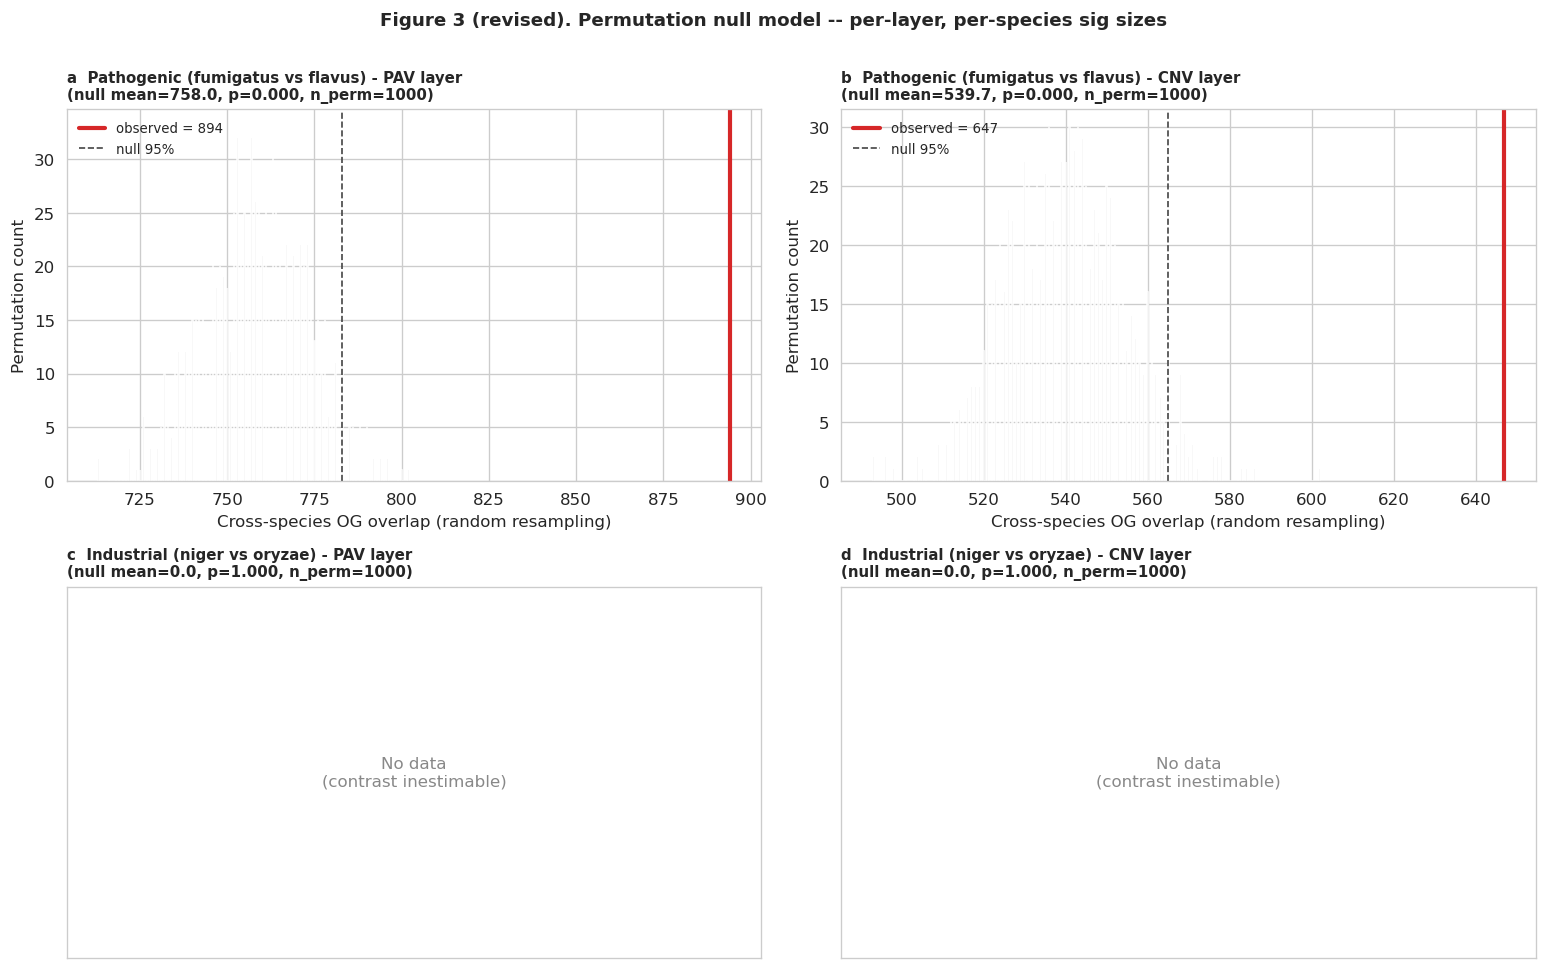

Saved: convergence_null_model.png


In [14]:
# --- Plot null model: 2x2 grid (PAV/CNV  x  pathogenic/industrial) ---
import matplotlib.pyplot as _plt
import numpy as _np

fig, axes = _plt.subplots(2, 2, figsize=(13, 8))
panels = [
    (axes[0, 0], null_path_pav, obs_path_pav, p_path_pav,
        'a  Pathogenic (fumigatus vs flavus) - PAV layer'),
    (axes[0, 1], null_path_cnv, obs_path_cnv, p_path_cnv,
        'b  Pathogenic (fumigatus vs flavus) - CNV layer'),
    (axes[1, 0], null_ind_pav, obs_ind_pav, p_ind_pav,
        'c  Industrial (niger vs oryzae) - PAV layer'),
    (axes[1, 1], null_ind_cnv, obs_ind_cnv, p_ind_cnv,
        'd  Industrial (niger vs oryzae) - CNV layer'),
]
for ax, nulls, obs, pval, title in panels:
    if nulls.max() <= 0 and obs == 0:
        ax.text(0.5, 0.5, 'No data\n(contrast inestimable)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='#888')
        ax.set_xticks([]); ax.set_yticks([])
    else:
        ax.hist(nulls, bins=max(15, int(nulls.max() + 1)),
                color='#cccccc', edgecolor='white', alpha=0.85)
        ax.axvline(obs, color='#d62728', linewidth=2.5,
                   label=f'observed = {int(obs)}')
        ax.axvline(_np.quantile(nulls, 0.95), color='#444',
                   linestyle='--', linewidth=1.0, label='null 95%')
        ax.set_xlabel('Cross-species OG overlap (random resampling)')
        ax.set_ylabel('Permutation count')
        ax.legend(frameon=False, fontsize=8)
    ax.set_title(title + f'\n(null mean={nulls.mean():.1f}, p={pval:.3f}, n_perm={N_PERMS})',
                 loc='left', fontsize=9, fontweight='bold')
fig.suptitle('Figure 3 (revised). Permutation null model -- per-layer, per-species sig sizes',
             fontsize=11, fontweight='bold', y=1.005)
_plt.tight_layout()
fig.savefig(os.path.join(str(NB3_RESULTS), 'convergence_null_model.png'),
            dpi=200, bbox_inches='tight')
_plt.show()
print('Saved: convergence_null_model.png')


In [15]:
# --- Interpretation: per-layer null model ---
print('Permutation Null Model Results (per-layer, per-species sig sizes)')
print('=' * 70)
for _, r in null_summary.iterrows():
    label = f"{r['contrast']} | {r['layer']}"
    if r['n_sp1_sig'] == 0 or r['n_sp2_sig'] == 0:
        print(f'  {label}: not testable (one species has 0 sig OGs in this layer).')
        continue
    print(f'  {label}:')
    print(f'    sp1 sig OGs={int(r["n_sp1_sig"])}, sp2 sig OGs={int(r["n_sp2_sig"])}')
    print(f'    observed overlap = {int(r["observed"])}, null mean = {r["null_mean"]:.1f}, '
          f'null 95% = {r["null_q95"]:.1f}, null max = {int(r["null_max"])}')
    print(f'    p = {r["p_value"]:.4f}  (N_PERMS = {int(r["n_perms"])})')
print()
print('Cross-species convergence: each contrast tested at PAV and CNV layer separately.')


Permutation Null Model Results (per-layer, per-species sig sizes)
  pathogenic (fumigatus vs flavus) | PAV:
    sp1 sig OGs=1690, sp2 sig OGs=1820
    observed overlap = 894, null mean = 758.0, null 95% = 783.0, null max = 802
    p = 0.0000  (N_PERMS = 1000)
  pathogenic (fumigatus vs flavus) | CNV:
    sp1 sig OGs=1594, sp2 sig OGs=1374
    observed overlap = 647, null mean = 539.7, null 95% = 565.0, null max = 602
    p = 0.0000  (N_PERMS = 1000)
  industrial (niger vs oryzae) | PAV: not testable (one species has 0 sig OGs in this layer).
  industrial (niger vs oryzae) | CNV: not testable (one species has 0 sig OGs in this layer).

Cross-species convergence: each contrast tested at PAV and CNV layer separately.


In [16]:
# --- Load OG consensus annotations from NB1 for each species ---
og_consensus = fpc.load_og_consensus_annotations(SPECIES_LIST, NB1_RESULTS)

fumigatus: loaded OG consensus from fumigatus_og_consensus.tsv ((10951, 23))
flavus: loaded OG consensus from flavus_og_consensus.tsv ((14463, 23))
niger: loaded OG consensus from niger_og_consensus.tsv ((12453, 23))
oryzae: loaded OG consensus from oryzae_og_consensus.tsv ((14279, 23))

Available columns (fumigatus): ['Orthogroup', 'Pangenome_Class', 'n_genomes', 'n_proteins', 'GOs', 'PFAMs', 'CAZy', 'EC', 'Description', 'COG_category', 'KEGG_ko', 'KEGG_Pathway', 'KEGG_TC', 'interpro_IPR', 'dbcan_Substrate', 'is_protease', 'protease_families', 'is_transporter', 'transporter_families', 'has_secretion_GO']


In [17]:
# --- Build cross-layer convergence summary ---
def _count_tested(mapped_dict, sp1, sp2, contrast_pattern):
    sp1_ogs = set(); sp2_ogs = set()
    for k, df in mapped_dict.items():
        if df.empty or 'combined_og' not in df.columns:
            continue
        if k.startswith(f'{sp1}__') and contrast_pattern in k:
            sp1_ogs |= set(df['combined_og'].dropna())
        if k.startswith(f'{sp2}__') and contrast_pattern in k:
            sp2_ogs |= set(df['combined_og'].dropna())
    return len(sp1_ogs & sp2_ogs)

def _split_dir(conv_df):
    """Return (n_convergent, n_discordant) from convergence DataFrame."""
    if conv_df.empty or 'category' not in conv_df.columns:
        return 0, 0
    counts = conv_df['category'].value_counts()
    return int(counts.get('CONVERGENT', 0)), int(counts.get('DISCORDANT', 0))

n_tested_pav_path = _count_tested(mapped_pav, 'fumigatus', 'flavus', 'human_pathogenic_vs_rest')
n_tested_cnv_path = _count_tested(mapped_cnv, 'fumigatus', 'flavus', 'human_pathogenic_vs_rest')
n_tested_pav_ind  = _count_tested(mapped_pav, 'niger', 'oryzae', 'industrial_trait_vs_rest')
n_tested_cnv_ind  = _count_tested(mapped_cnv, 'niger', 'oryzae', 'industrial_trait_vs_rest')

n_conv_pav_p, n_disc_pav_p = _split_dir(path_pav_conv)
n_conv_cnv_p, n_disc_cnv_p = _split_dir(path_cnv_conv)
n_conv_pav_i, n_disc_pav_i = _split_dir(ind_pav_conv)
n_conv_cnv_i, n_disc_cnv_i = _split_dir(ind_cnv_conv)

rows = [
    ('PAV (pathogenic: fumigatus vs flavus)',
     n_tested_pav_path, n_conv_pav_p + n_disc_pav_p, n_conv_pav_p, n_disc_pav_p),
    ('CNV (pathogenic: fumigatus vs flavus)',
     n_tested_cnv_path, n_conv_cnv_p + n_disc_cnv_p, n_conv_cnv_p, n_disc_cnv_p),
    ('PAV (industrial: niger vs oryzae)',
     n_tested_pav_ind, n_conv_pav_i + n_disc_pav_i, n_conv_pav_i, n_disc_pav_i),
    ('CNV (industrial: niger vs oryzae)',
     n_tested_cnv_ind, n_conv_cnv_i + n_disc_cnv_i, n_conv_cnv_i, n_disc_cnv_i),
]
convergence_summary = pd.DataFrame(rows, columns=[
    'layer', 'n_tested', 'n_shared_sig', 'n_convergent_same_dir', 'n_discordant'
])
convergence_summary['%_convergent'] = (
    100 * convergence_summary['n_convergent_same_dir']
    / convergence_summary['n_tested'].replace(0, np.nan)
).round(2)
convergence_summary['conv:disc_ratio'] = convergence_summary.apply(
    lambda r: f"{r['n_convergent_same_dir']}:{r['n_discordant']}"
              if (r['n_convergent_same_dir'] + r['n_discordant']) > 0 else 'n/a',
    axis=1,
)


In [18]:
# --- Summary: Convergence across all layers ---
print('Convergence Summary by Layer')
print('=' * 60)
if 'convergence_summary' in dir():
    display(convergence_summary)
    convergence_summary.to_csv(os.path.join(str(NB3_RESULTS), 'convergence_summary_by_layer.csv'), index=False)
    print(f'\nSaved to NB3_Results/convergence_summary_by_layer.csv')
else:
    print('  (Run convergence sections above first)')


Convergence Summary by Layer


,layer,n_tested,n_shared_sig,n_convergent_same_dir,n_discordant,%_convergent,conv:disc_ratio
0,PAV (pathogenic: fumigatus vs flavus),3628,894,441,453,12.16,441:453
1,CNV (pathogenic: fumigatus vs flavus),3628,647,316,331,8.71,316:331
2,PAV (industrial: niger vs oryzae),0,0,0,0,NaN,n/a
3,CNV (industrial: niger vs oryzae),0,0,0,0,NaN,n/a



Saved to NB3_Results/convergence_summary_by_layer.csv


---
## Section 7: Cross-species family-level comparisons (CAZy / Protease / Secretome)

Whereas convergence in Sections 3-6 was tested at the orthogroup level, this
section asks whether functional *family* compositions differ across the four
species at the pangenome level. We use the og_consensus annotations directly:

- CAZy: per-family OG counts and core/accessory/rare partition per species.
- Protease: OGs flagged `is_protease` and their `protease_families`.
- Secretome: OGs flagged `is_secreted_signalp` (high-confidence signal peptide).

Outputs: `cazy_family_comparison.csv`, `cazy_cross_species_comparison.png`,
`protease_family_comparison.csv`, `protease_cross_species_comparison.png`,
`secretome_comparison.csv`, `secretome_cross_species_comparison.png`.


CAZy: 273 families across 4 species
Top 15 most-shared CAZy families:
species  flavus  fumigatus  niger  oryzae  total
family                                          
GH3         108         84     72     101    365
GT2          86         71     72      87    316
GT0          83         61     69      80    293
GH18         77         55     66      82    280
AA3_2        70         46     70      70    256
GT1          69         50     62      68    249
GH28         54         35     46      53    188
GH76         45         38     43      46    172
AA7          50         26     42      47    165
GH47         44         35     38      42    159
GH0          44         32     38      43    157
AA9          43         28     34      41    146
GH72         40         27     32      43    142
CBM50        37         26     32      38    133
GH92         34         24     31      38    127


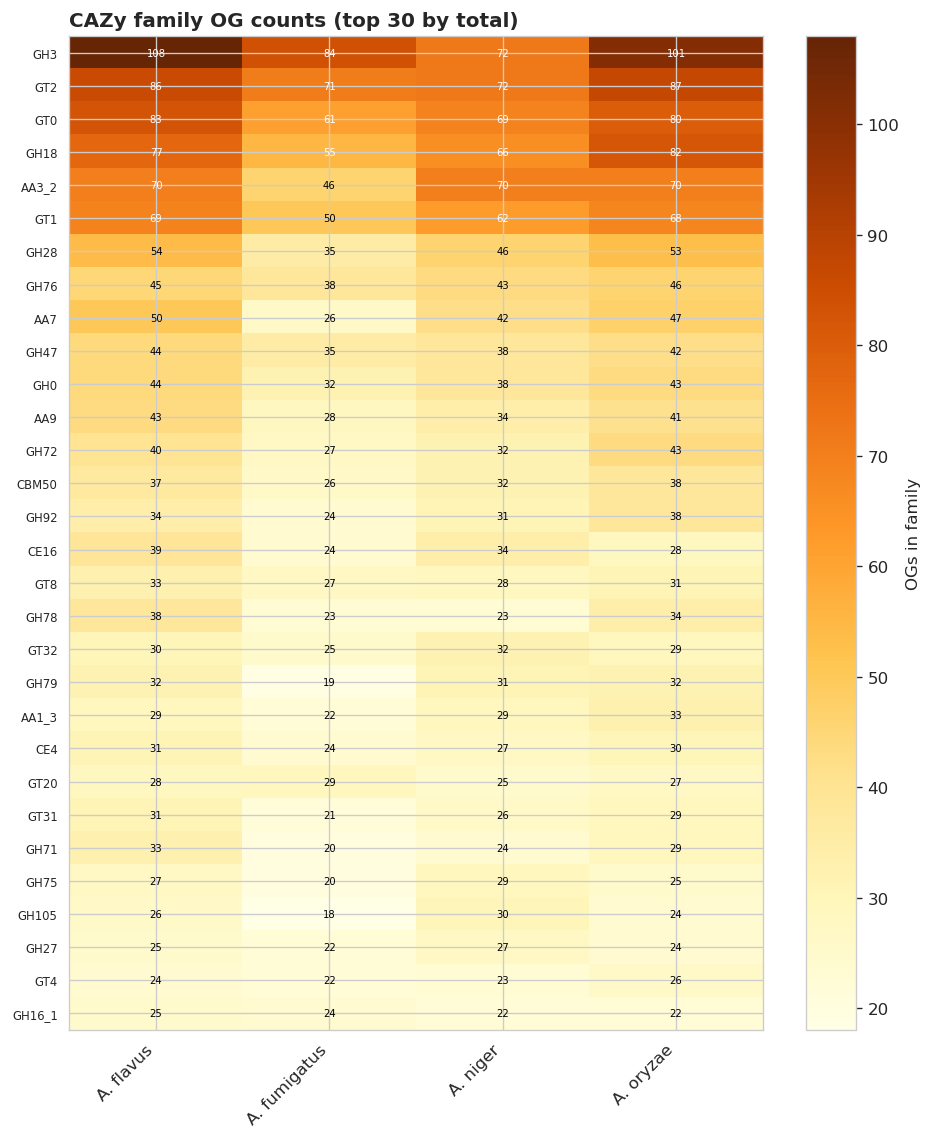

Saved: cazy_cross_species_comparison.png


In [19]:
# --- 7.1: CAZy family cross-species comparison ---
import collections, matplotlib.pyplot as _plt

cazy_rows = []
for sp in SPECIES_LIST:
    if sp not in og_consensus or og_consensus[sp].empty:
        continue
    ogc = og_consensus[sp]
    pclass_col = 'Pangenome_Class' if 'Pangenome_Class' in ogc.columns else None
    cazy = ogc['CAZy'].dropna()
    for og_idx, terms in cazy.items():
        pclass = ogc.loc[og_idx, pclass_col] if pclass_col else 'Unknown'
        for term in str(terms).split(';'):
            term = term.strip()
            if term and term != 'nan':
                cazy_rows.append({'species': sp, 'family': term,
                                  'pangenome_class': pclass})
cazy_df = pd.DataFrame(cazy_rows)
cazy_pivot = cazy_df.groupby(['family', 'species']).size().unstack(fill_value=0)
cazy_pivot['total'] = cazy_pivot.sum(axis=1)
cazy_pivot = cazy_pivot.sort_values('total', ascending=False)
cazy_pivot.to_csv(os.path.join(str(NB3_RESULTS), 'cazy_family_comparison.csv'))
print(f'CAZy: {len(cazy_pivot)} families across {len(SPECIES_LIST)} species')
print(f'Top 15 most-shared CAZy families:')
print(cazy_pivot.head(15).to_string())

# Heatmap of top 30
top_n = 30
top = cazy_pivot.drop(columns='total').head(top_n)
fig, ax = _plt.subplots(figsize=(8, max(8, top_n * 0.32)))
import numpy as _np
im = ax.imshow(top.values, aspect='auto', cmap='YlOrBr')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
ax.set_xticks(range(len(top.columns))); ax.set_xticklabels(
    [f'A. {c}' for c in top.columns], rotation=45, ha='right')
for i in range(top.shape[0]):
    for j in range(top.shape[1]):
        ax.text(j, i, int(top.iloc[i, j]), ha='center', va='center',
                fontsize=6,
                color='white' if top.iloc[i, j] > top.values.max() / 2 else 'black')
_plt.colorbar(im, ax=ax, label='OGs in family')
ax.set_title(f'CAZy family OG counts (top {top_n} by total)',
             loc='left', fontweight='bold')
_plt.tight_layout()
fig.savefig(os.path.join(str(NB3_RESULTS), 'cazy_cross_species_comparison.png'),
            dpi=200, bbox_inches='tight')
_plt.show()
print('Saved: cazy_cross_species_comparison.png')


  fumigatus: 6 protease OGs
  flavus: 11 protease OGs
  niger: 9 protease OGs
  oryzae: 9 protease OGs


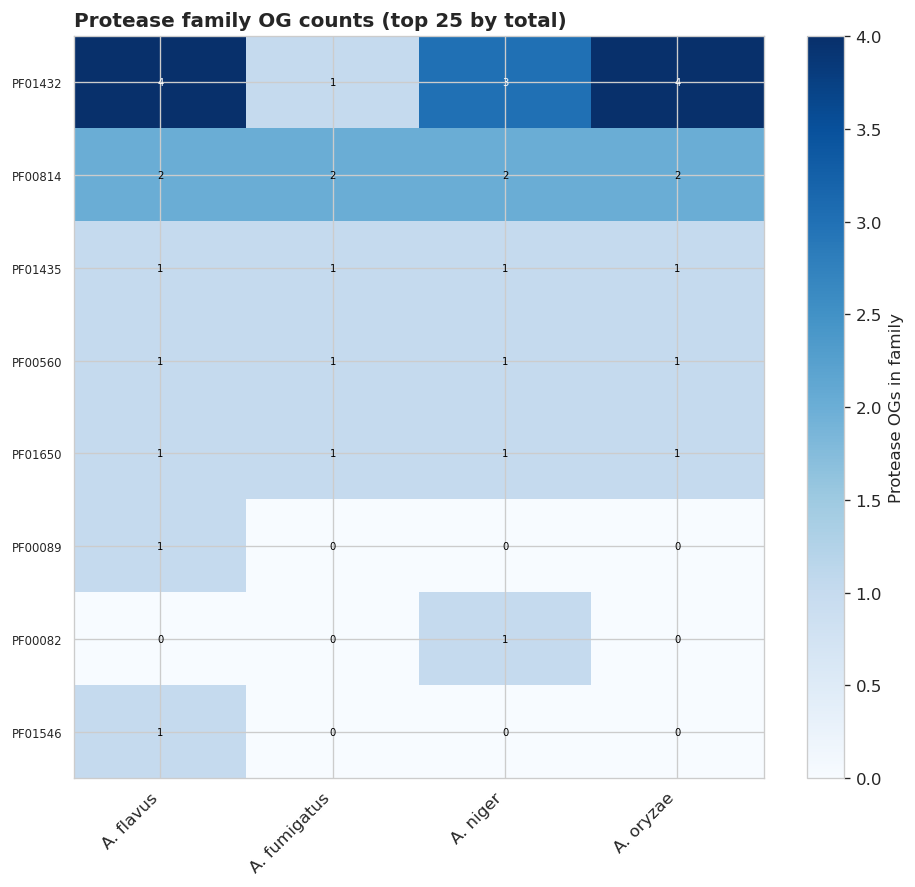

Saved: protease_cross_species_comparison.png and protease_family_comparison.csv


In [20]:
# --- 7.2: Protease family cross-species comparison ---
prot_rows = []
for sp in SPECIES_LIST:
    if sp not in og_consensus or og_consensus[sp].empty:
        continue
    ogc = og_consensus[sp]
    if 'is_protease' not in ogc.columns:
        continue
    proteases = ogc[ogc['is_protease'] == True]
    for og_idx, fam in proteases['protease_families'].dropna().items():
        pclass = ogc.loc[og_idx, 'Pangenome_Class'] if 'Pangenome_Class' in ogc.columns else 'Unknown'
        for f in str(fam).split(';'):
            f = f.strip()
            if f and f != 'nan':
                prot_rows.append({'species': sp, 'family': f, 'pangenome_class': pclass})
    n_total = len(proteases)
    print(f'  {sp}: {n_total} protease OGs')
prot_df = pd.DataFrame(prot_rows)
if prot_df.empty:
    print('No protease annotations available; skipping plot.')
else:
    prot_pivot = prot_df.groupby(['family', 'species']).size().unstack(fill_value=0)
    prot_pivot['total'] = prot_pivot.sum(axis=1)
    prot_pivot = prot_pivot.sort_values('total', ascending=False)
    prot_pivot.to_csv(os.path.join(str(NB3_RESULTS), 'protease_family_comparison.csv'))
    top_n = 25
    top = prot_pivot.drop(columns='total').head(top_n)
    fig, ax = _plt.subplots(figsize=(8, max(6, top_n * 0.3)))
    im = ax.imshow(top.values, aspect='auto', cmap='Blues')
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
    ax.set_xticks(range(len(top.columns))); ax.set_xticklabels(
        [f'A. {c}' for c in top.columns], rotation=45, ha='right')
    for i in range(top.shape[0]):
        for j in range(top.shape[1]):
            ax.text(j, i, int(top.iloc[i, j]), ha='center', va='center', fontsize=6,
                    color='white' if top.iloc[i, j] > top.values.max() / 2 else 'black')
    _plt.colorbar(im, ax=ax, label='Protease OGs in family')
    ax.set_title(f'Protease family OG counts (top {top_n} by total)',
                 loc='left', fontweight='bold')
    _plt.tight_layout()
    fig.savefig(os.path.join(str(NB3_RESULTS), 'protease_cross_species_comparison.png'),
                dpi=200, bbox_inches='tight')
    _plt.show()
    print('Saved: protease_cross_species_comparison.png and protease_family_comparison.csv')


  species  n_total_OGs  n_secreted_signalp  pct_secreted_signalp  n_secretion_GO  n_secreted_in_Core  n_secreted_in_Accessory  n_secreted_in_Rare
fumigatus        10951                 833              7.606611               0                 685                      102                  46
   flavus        14463                1269              8.774113               0                1035                      191                  43
    niger        12453                 941              7.556412               0                 778                      147                  16
   oryzae        14279                1194              8.361930               1                1001                      169                  24


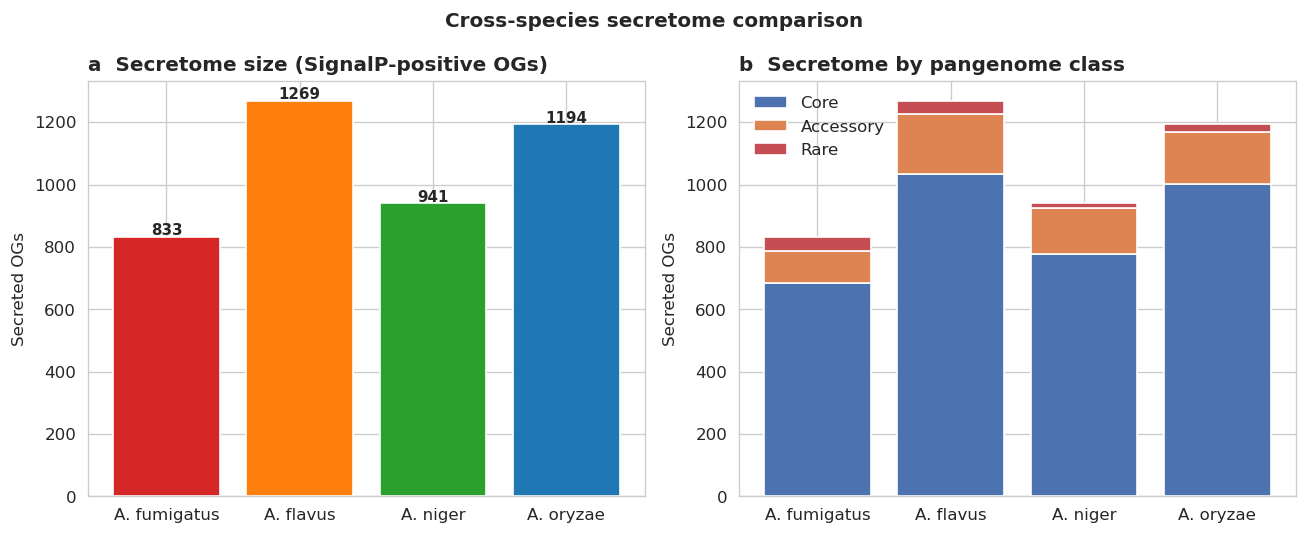

Saved: secretome_cross_species_comparison.png and secretome_comparison.csv


In [21]:
# --- 7.3: Secretome cross-species comparison ---
import numpy as _np
secretome_rows = []
for sp in SPECIES_LIST:
    if sp not in og_consensus or og_consensus[sp].empty:
        continue
    ogc = og_consensus[sp]
    n_total = len(ogc)
    n_secreted = int(ogc['is_secreted_signalp'].fillna(False).astype(bool).sum()) \
        if 'is_secreted_signalp' in ogc.columns else 0
    n_secreted_GO = int(ogc['has_secretion_GO'].fillna(False).astype(bool).sum()) \
        if 'has_secretion_GO' in ogc.columns else 0
    pclass_breakdown = {}
    if 'Pangenome_Class' in ogc.columns and 'is_secreted_signalp' in ogc.columns:
        sub = ogc[ogc['is_secreted_signalp'].fillna(False).astype(bool)]
        pclass_breakdown = sub['Pangenome_Class'].value_counts().to_dict()
    secretome_rows.append({
        'species': sp, 'n_total_OGs': n_total,
        'n_secreted_signalp': n_secreted,
        'pct_secreted_signalp': 100.0 * n_secreted / max(1, n_total),
        'n_secretion_GO': n_secreted_GO,
        'n_secreted_in_Core': pclass_breakdown.get('Core', 0),
        'n_secreted_in_Accessory': pclass_breakdown.get('Accessory', 0),
        'n_secreted_in_Rare': pclass_breakdown.get('Rare', 0),
    })
secretome_df = pd.DataFrame(secretome_rows)
if secretome_df.empty:
    print('No secretome annotations available; skipping.')
else:
    secretome_df.to_csv(os.path.join(str(NB3_RESULTS), 'secretome_comparison.csv'),
                        index=False)
    print(secretome_df.to_string(index=False))
    fig, axes = _plt.subplots(1, 2, figsize=(11, 4.5))
    sp_lbls = [f'A. {s}' for s in secretome_df['species']]
    axes[0].bar(sp_lbls, secretome_df['n_secreted_signalp'],
                color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
    for i, v in enumerate(secretome_df['n_secreted_signalp']):
        axes[0].text(i, v + 5, str(int(v)), ha='center', fontweight='bold', fontsize=9)
    axes[0].set_title('a  Secretome size (SignalP-positive OGs)',
                      loc='left', fontweight='bold')
    axes[0].set_ylabel('Secreted OGs')
    bottom = _np.zeros(len(secretome_df))
    for cls, color in [('Core', '#4c72b0'),
                       ('Accessory', '#dd8452'),
                       ('Rare', '#c44e52')]:
        vals = secretome_df[f'n_secreted_in_{cls}'].values
        axes[1].bar(sp_lbls, vals, bottom=bottom, label=cls, color=color)
        bottom += vals
    axes[1].set_title('b  Secretome by pangenome class',
                      loc='left', fontweight='bold')
    axes[1].set_ylabel('Secreted OGs'); axes[1].legend(frameon=False)
    _plt.suptitle('Cross-species secretome comparison', fontweight='bold')
    _plt.tight_layout()
    fig.savefig(os.path.join(str(NB3_RESULTS),
                              'secretome_cross_species_comparison.png'),
                dpi=200, bbox_inches='tight')
    _plt.show()
    print('Saved: secretome_cross_species_comparison.png and secretome_comparison.csv')


---
## Section 8: Functional convergence with permutation null model

Section 3-6 tested cross-species convergence at the **orthogroup identity** level.
This section asks the complementary question: even where two species share no
individual orthogroups, do they perturb the same **functional categories**
(CAZy, Pfam, COG, KEGG, GO, InterPro, EC, dbCAN substrates)?

Two complementary tests:

- **8a (term intersection):** for each species pair x contrast x layer, take
  the functional terms attached to each species's GWAS-significant OGs,
  intersect across species, report shared terms and Jaccard.
- **8b (Jaccard permutation null):** for each layer, draw N=1000 random OG
  sets of the same size as each species's actual sig set from each species's
  tested OG pool, compute Jaccard of functional-term sets, build null
  distribution. Compare observed Jaccard to null. Per-(species pair, contrast)
  Benjamini-Hochberg FDR correction across the 10 layers.

Outputs: `functional_convergence_results.csv` with columns `sp1, sp2, contrast,
layer, n_sig_*, n_shared_terms, observed_jaccard, null_mean, null_q95,
p_value, q_value, significant, shared_terms`.


In [22]:
# --- Section 8: Functional convergence (4a + 4b) ---
import glob, time
from statsmodels.stats.multitest import multipletests as _mt

FUNCTIONAL_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']
FUNC_CONV_N_PERM = 1000

def _precompute_og_to_terms(og_consensus, layers):
    """Build OG -> {term} per layer, dropping uninformative annotations
    (COG-S/R, Pfam DUFs, GO root nodes, EC -.-.-.-) so they are excluded from
    Jaccard set construction."""
    from funpan_utils import is_informative_term as _info
    out = {}
    for layer in layers:
        if layer not in og_consensus.columns:
            continue
        out[layer] = {}
        for _, row in og_consensus.iterrows():
            v = row.get(layer)
            if pd.isna(v):
                continue
            terms = {t.strip() for t in str(v).split(';')
                     if t.strip() and t.strip() != 'nan'}
            terms = {t for t in terms if _info(layer, t)}
            if terms:
                out[layer][row['Orthogroup']] = terms
    return out

def _terms_for_og_set(og_set, og_to_terms_layer):
    out = set()
    for og in og_set:
        ts = og_to_terms_layer.get(og)
        if ts:
            out |= ts
    return out

def _jaccard(a, b):
    if not a and not b:
        return 0.0
    union = a | b
    return len(a & b) / len(union) if union else 0.0

def _get_sig_and_bg_ogs(species, contrast, layers=('pav', 'cnv')):
    sig, bg = set(), set()
    for layer in layers:
        fp = f'{NB2_RESULTS}/{species}/pangwas_results/{layer}_assoc_{contrast}.tsv'
        if not glob.glob(fp):
            continue
        df = pd.read_csv(fp, sep='\t')
        if 'feature' not in df.columns:
            continue
        bg.update(df['feature'].astype(str).tolist())
        if 'significant' in df.columns:
            sig.update(df.loc[df['significant'], 'feature'].astype(str).tolist())
    return sig, bg

def _functional_convergence_pair(sp1, sp2, contrast, layers,
                                 n_perm=FUNC_CONV_N_PERM, seed=42):
    sig1, bg1 = _get_sig_and_bg_ogs(sp1, contrast)
    sig2, bg2 = _get_sig_and_bg_ogs(sp2, contrast)
    print(f'\n  {sp1} vs {sp2} | {contrast}: '
          f'{len(sig1)} vs {len(sig2)} sig OGs')
    if len(sig1) == 0 or len(sig2) == 0:
        print('    -> NOT TESTABLE (one species has 0 sig OGs)')
        return None
    o2t1 = _precompute_og_to_terms(og_consensus[sp1], layers)
    o2t2 = _precompute_og_to_terms(og_consensus[sp2], layers)
    bg1_arr = _np.array(sorted(bg1))
    bg2_arr = _np.array(sorted(bg2))
    rows = []
    for layer in layers:
        if layer not in o2t1 or layer not in o2t2:
            continue
        sig1_terms = _terms_for_og_set(sig1, o2t1[layer])
        sig2_terms = _terms_for_og_set(sig2, o2t2[layer])
        observed_J = _jaccard(sig1_terms, sig2_terms)
        observed_shared = sig1_terms & sig2_terms
        n1 = min(len(sig1), len(bg1_arr)); n2 = min(len(sig2), len(bg2_arr))
        rng_layer = _np.random.default_rng(seed + (hash(layer) % 10000))
        null_J = _np.zeros(n_perm)
        for k in range(n_perm):
            s1_rand = set(rng_layer.choice(bg1_arr, size=n1, replace=False))
            s2_rand = set(rng_layer.choice(bg2_arr, size=n2, replace=False))
            t1 = _terms_for_og_set(s1_rand, o2t1[layer])
            t2 = _terms_for_og_set(s2_rand, o2t2[layer])
            null_J[k] = _jaccard(t1, t2)
        p = float((null_J >= observed_J).sum()) / max(1, len(null_J))
        rows.append({
            'sp1': sp1, 'sp2': sp2, 'contrast': contrast, 'layer': layer,
            'n_sig_sp1': len(sig1), 'n_sig_sp2': len(sig2),
            'n_terms_sp1_sig': len(sig1_terms),
            'n_terms_sp2_sig': len(sig2_terms),
            'n_shared_terms': len(observed_shared),
            'observed_jaccard': observed_J,
            'null_mean_jaccard': float(null_J.mean()),
            'null_q95_jaccard': float(_np.quantile(null_J, 0.95)),
            'p_value': p,
            'shared_terms': ';'.join(sorted(observed_shared)[:30]),
        })
    df = pd.DataFrame(rows)
    return df

# --- Run for all testable contrasts ---
_pairs = [
    ('fumigatus','flavus','human_pathogenic_vs_rest'),
    ('fumigatus','flavus','environmental_vs_rest'),
    ('niger','oryzae','industrial_trait_vs_rest'),
    ('niger','oryzae','environmental_vs_rest'),
    ('flavus','niger','environmental_vs_rest'),
]
import numpy as _np
_t0 = time.time()
_results = []
for sp1, sp2, contrast in _pairs:
    res = _functional_convergence_pair(sp1, sp2, contrast, FUNCTIONAL_LAYERS)
    if res is not None and len(res):
        _results.append(res)
_elapsed = time.time() - _t0
print(f'\n  Completed {len(_results)} pair x contrast in {_elapsed:.0f}s')

if _results:
    func_conv_df = pd.concat(_results, ignore_index=True)
    func_conv_df['q_value'] = 1.0
    for (sp1, sp2, c), grp in func_conv_df.groupby(['sp1', 'sp2', 'contrast']):
        func_conv_df.loc[grp.index, 'q_value'] = _mt(grp['p_value'], method='fdr_bh')[1]
    func_conv_df['significant'] = func_conv_df['q_value'] < 0.05
    func_conv_df.to_csv(os.path.join(str(NB3_RESULTS),
                                     'functional_convergence_results.csv'),
                        index=False)
    print(f'\n  Saved: NB3_Results/functional_convergence_results.csv')
    n_sig = int(func_conv_df['significant'].sum())
    print(f'\n  Significant functional convergence (q<0.05 per pair/contrast): {n_sig}')
    if n_sig:
        print(func_conv_df[func_conv_df['significant']][
            ['sp1','sp2','contrast','layer','n_shared_terms',
             'observed_jaccard','null_mean_jaccard','p_value','q_value',
             'shared_terms']].to_string(index=False))
    else:
        print('\n  Top 5 trends by p_value (none survive FDR):')
        print(func_conv_df.sort_values('p_value').head(5)[
            ['sp1','sp2','contrast','layer','n_shared_terms',
             'observed_jaccard','null_mean_jaccard','p_value']].to_string(index=False))
else:
    print('\n  All pairs have at least one species with 0 sig OGs; functional convergence not testable.')



  fumigatus vs flavus | human_pathogenic_vs_rest: 95 vs 63 sig OGs

  fumigatus vs flavus | environmental_vs_rest: 95 vs 29 sig OGs

  niger vs oryzae | industrial_trait_vs_rest: 2 vs 0 sig OGs
    -> NOT TESTABLE (one species has 0 sig OGs)

  niger vs oryzae | environmental_vs_rest: 114 vs 0 sig OGs
    -> NOT TESTABLE (one species has 0 sig OGs)

  flavus vs niger | environmental_vs_rest: 29 vs 114 sig OGs

  Completed 3 pair x contrast in 24s

  Saved: NB3_Results/functional_convergence_results.csv

  Significant functional convergence (q<0.05 per pair/contrast): 0

  Top 5 trends by p_value (none survive FDR):
      sp1    sp2                 contrast        layer  n_shared_terms  observed_jaccard  null_mean_jaccard  p_value
fumigatus flavus    environmental_vs_rest         CAZy               1          0.142857           0.034496    0.043
fumigatus flavus human_pathogenic_vs_rest KEGG_Pathway               3          0.166667           0.074046    0.062
   flavus  niger    envir

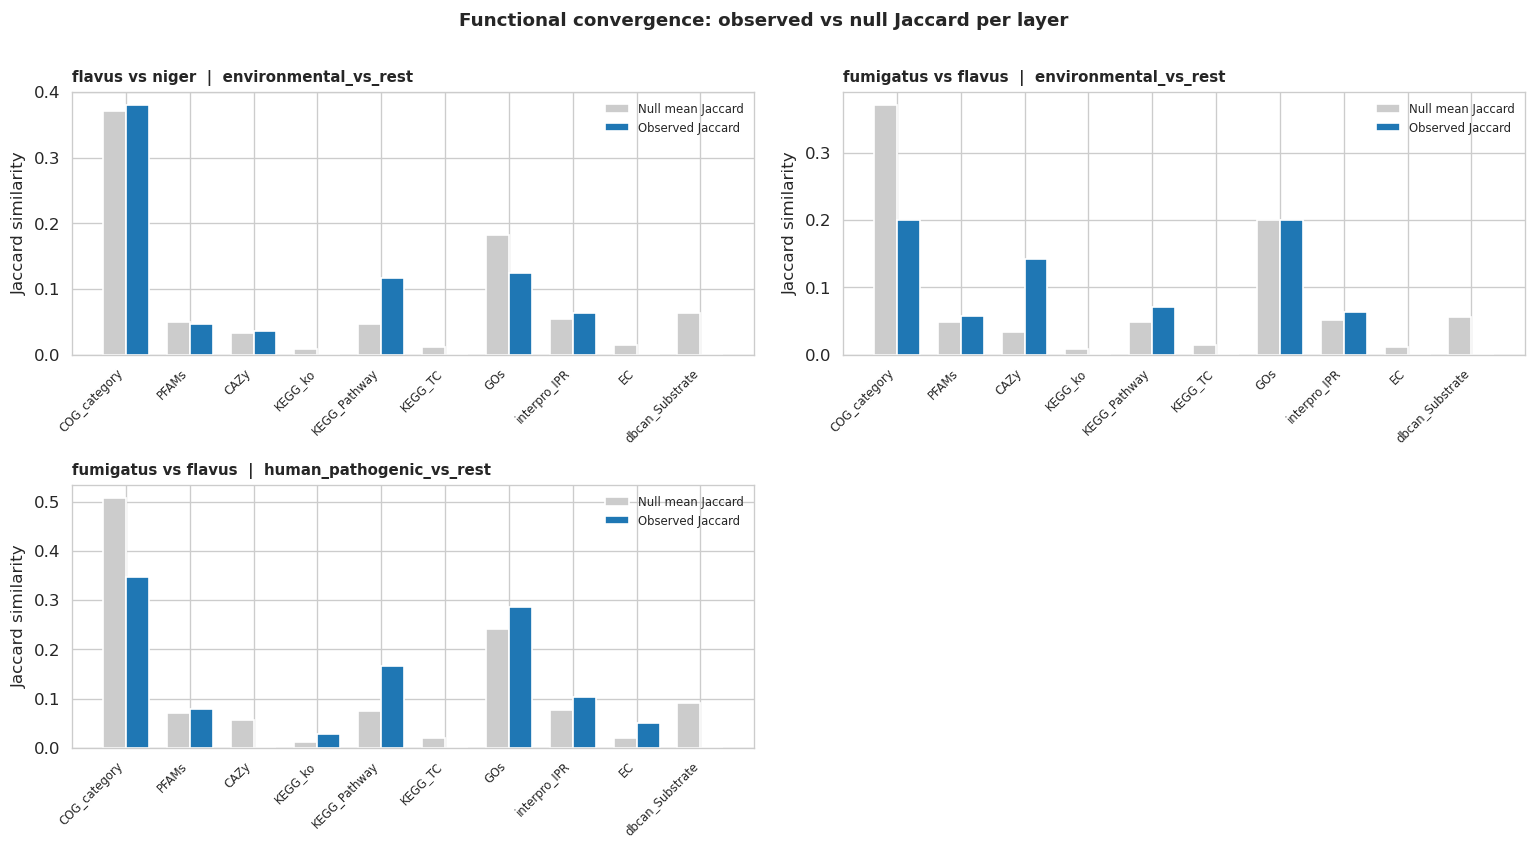

Saved: NB3_Results/functional_convergence.png


In [23]:
# --- Section 8 figure: per-pair Jaccard observed vs null ---
if _results:
    import matplotlib.pyplot as _plt
    pairs_with_data = func_conv_df.groupby(['sp1','sp2','contrast']).size().index.tolist()
    n_panels = len(pairs_with_data)
    if n_panels:
        ncols = 2; nrows = (n_panels + ncols - 1) // ncols
        fig, axes = _plt.subplots(nrows, ncols, figsize=(13, 3.5 * nrows),
                                  squeeze=False)
        for ax, (sp1, sp2, c) in zip(axes.flatten(), pairs_with_data):
            sub = func_conv_df[(func_conv_df['sp1']==sp1) &
                                (func_conv_df['sp2']==sp2) &
                                (func_conv_df['contrast']==c)].copy()
            x = _np.arange(len(sub))
            ax.bar(x - 0.18, sub['null_mean_jaccard'], width=0.36,
                   color='#cccccc', edgecolor='white', label='Null mean Jaccard')
            ax.bar(x + 0.18, sub['observed_jaccard'], width=0.36,
                   color=['#d62728' if s else '#1f77b4' for s in sub['significant']],
                   edgecolor='white', label='Observed Jaccard')
            ax.set_xticks(x)
            ax.set_xticklabels(sub['layer'], rotation=45, ha='right', fontsize=7)
            ax.set_ylabel('Jaccard similarity')
            ax.set_title(f'{sp1} vs {sp2}  |  {c}', loc='left',
                         fontsize=9, fontweight='bold')
            for xi, q in zip(x, sub['q_value']):
                if q < 0.05:
                    ax.text(xi, sub['observed_jaccard'].iloc[xi] + 0.01,
                            f'q={q:.2f}', fontsize=7, ha='center')
            ax.legend(frameon=False, fontsize=7)
        # Hide unused panels
        for ax in axes.flatten()[n_panels:]:
            ax.axis('off')
        fig.suptitle('Functional convergence: observed vs null Jaccard per layer',
                     fontsize=11, fontweight='bold', y=1.005)
        _plt.tight_layout()
        fig.savefig(os.path.join(str(NB3_RESULTS),
                                 'functional_convergence.png'),
                    dpi=200, bbox_inches='tight')
        _plt.show()
        print('Saved: NB3_Results/functional_convergence.png')
else:
    print('No functional convergence data to plot.')


---
## Section 9: Per-term meta-analytic functional convergence

Section 8 tested whether the *sets* of significantly-enriched functional
terms in two species are more similar than expected by chance (Jaccard
permutation null). Section 9 complements this by testing each individual
term: for every (annotation layer, term) tested in both species's GWAS
functional enrichment under the same contrast, we combine the per-species
raw p-values via Fisher's method:

    chi2 = -2 * (ln(p_sp1) + ln(p_sp2)),  df = 4

and require directional concordance (same enrichment sign in both species,
OR > 1 in both). Per-(species pair, contrast, layer) Benjamini-Hochberg
FDR is applied across terms. Output: `functional_term_meta_convergence.csv`
with columns `sp1, sp2, contrast, layer, term, OR_sp1, OR_sp2, p_sp1,
p_sp2, fisher_combined_p, q_value, direction_concordant, significant`.


In [24]:
# --- Section 9: per-term meta-analytic functional convergence ---
from scipy.stats import combine_pvalues as _combine_p
from statsmodels.stats.multitest import multipletests as _mt9

def _meta_convergence_pair(sp1, sp2, contrast):
    fp1 = f'NB2_Results/{sp1}/{sp1}_functional_enrichment.csv'
    fp2 = f'NB2_Results/{sp2}/{sp2}_functional_enrichment.csv'
    if not (os.path.exists(fp1) and os.path.exists(fp2)):
        return None
    e1 = pd.read_csv(fp1); e2 = pd.read_csv(fp2)
    if 'contrast' in e1.columns:
        e1 = e1[e1['contrast'] == contrast]
    if 'contrast' in e2.columns:
        e2 = e2[e2['contrast'] == contrast]
    if e1.empty or e2.empty:
        return None
    rows = []
    for layer, l1 in e1.groupby('annotation_layer'):
        l2 = e2[e2['annotation_layer'] == layer]
        if l2.empty:
            continue
        l1i = l1.set_index('term')
        l2i = l2.set_index('term')
        shared_terms = l1i.index.intersection(l2i.index)
        for term in shared_terms:
            r1 = l1i.loc[term]; r2 = l2i.loc[term]
            p1 = float(r1['pvalue']); p2 = float(r2['pvalue'])
            or1 = float(r1['odds_ratio']); or2 = float(r2['odds_ratio'])
            # Floor p at 1e-300 for combine_pvalues stability
            p1_safe = max(p1, 1e-300); p2_safe = max(p2, 1e-300)
            stat, comb_p = _combine_p([p1_safe, p2_safe], method='fisher')
            # Direction: BOTH enriched (OR > 1) or BOTH depleted (OR < 1)
            both_enriched = (or1 > 1) and (or2 > 1)
            both_depleted = (or1 < 1) and (or2 < 1)
            direction_concordant = both_enriched or both_depleted
            rows.append({
                'sp1': sp1, 'sp2': sp2, 'contrast': contrast, 'layer': layer,
                'term': term,
                'OR_sp1': or1, 'OR_sp2': or2,
                'p_sp1': p1, 'p_sp2': p2,
                'n_sig_sp1': int(r1.get('n_sig_with_term', 0)),
                'n_sig_sp2': int(r2.get('n_sig_with_term', 0)),
                'n_bg_sp1': int(r1.get('n_bg_with_term', 0)),
                'n_bg_sp2': int(r2.get('n_bg_with_term', 0)),
                'fisher_combined_p': float(comb_p),
                'direction_concordant': direction_concordant,
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return None
    # Per-(species pair, contrast, layer) FDR
    df['q_value'] = 1.0
    for layer, grp in df.groupby('layer'):
        df.loc[grp.index, 'q_value'] = _mt9(grp['fisher_combined_p'],
                                             method='fdr_bh')[1]
    df['significant'] = (df['q_value'] < 0.05) & df['direction_concordant']
    return df

_meta_pairs = [
    ('fumigatus','flavus','human_pathogenic_vs_rest'),
    ('fumigatus','flavus','environmental_vs_rest'),
    ('niger','oryzae','industrial_trait_vs_rest'),
    ('niger','oryzae','environmental_vs_rest'),
    ('flavus','niger','environmental_vs_rest'),
]
_meta_results = []
for sp1, sp2, contrast in _meta_pairs:
    res = _meta_convergence_pair(sp1, sp2, contrast)
    if res is not None:
        _meta_results.append(res)
        n_sig = int(res['significant'].sum())
        print(f'  {sp1} vs {sp2} | {contrast}: '
              f'{len(res)} testable terms, {n_sig} significant + concordant '
              f'(q<0.05, both same direction)')

if _meta_results:
    meta_df = pd.concat(_meta_results, ignore_index=True)
    meta_df.to_csv(os.path.join(str(NB3_RESULTS),
                                'functional_term_meta_convergence.csv'),
                   index=False)
    print(f'\n  Saved: NB3_Results/functional_term_meta_convergence.csv'
          f'  ({len(meta_df)} rows)')
    print(f'\n  Significant + concordant terms (q<0.05): {int(meta_df["significant"].sum())}')
    if meta_df['significant'].sum():
        sig = meta_df[meta_df['significant']].sort_values('q_value')
        print(sig[['sp1','sp2','contrast','layer','term',
                   'OR_sp1','OR_sp2','p_sp1','p_sp2',
                   'fisher_combined_p','q_value']].to_string(index=False))
    else:
        print('\n  Top 10 directionally-concordant terms by combined p:')
        conc = meta_df[meta_df['direction_concordant']].sort_values('fisher_combined_p').head(10)
        print(conc[['sp1','sp2','contrast','layer','term',
                    'OR_sp1','OR_sp2','p_sp1','p_sp2',
                    'fisher_combined_p','q_value']].to_string(index=False))
else:
    print('No testable species pair x contrast for meta-analytic functional convergence.')


  fumigatus vs flavus | human_pathogenic_vs_rest: 222 testable terms, 0 significant + concordant (q<0.05, both same direction)
  fumigatus vs flavus | environmental_vs_rest: 222 testable terms, 0 significant + concordant (q<0.05, both same direction)
  flavus vs niger | environmental_vs_rest: 355 testable terms, 0 significant + concordant (q<0.05, both same direction)

  Saved: NB3_Results/functional_term_meta_convergence.csv  (799 rows)

  Significant + concordant terms (q<0.05): 0

  Top 10 directionally-concordant terms by combined p:
      sp1    sp2                 contrast        layer       term    OR_sp1    OR_sp2    p_sp1    p_sp2  fisher_combined_p  q_value
   flavus  niger    environmental_vs_rest interpro_IPR  IPR032466 35.464286 10.758929 0.037991 0.022927           0.007008 0.742852
   flavus  niger    environmental_vs_rest COG_category          F 15.703704  2.921266 0.009888 0.165335           0.012124 0.351598
fumigatus flavus human_pathogenic_vs_rest        PFAMs ADH_z

---
## Section 10: Combined summary figures (add-on)

Four combined plots aggregating outputs from earlier sections of this notebook:
cross-species convergence summary, CAZy/protease family heatmaps, secretome
(size + pangenome-class composition), and functional convergence per annotation layer.


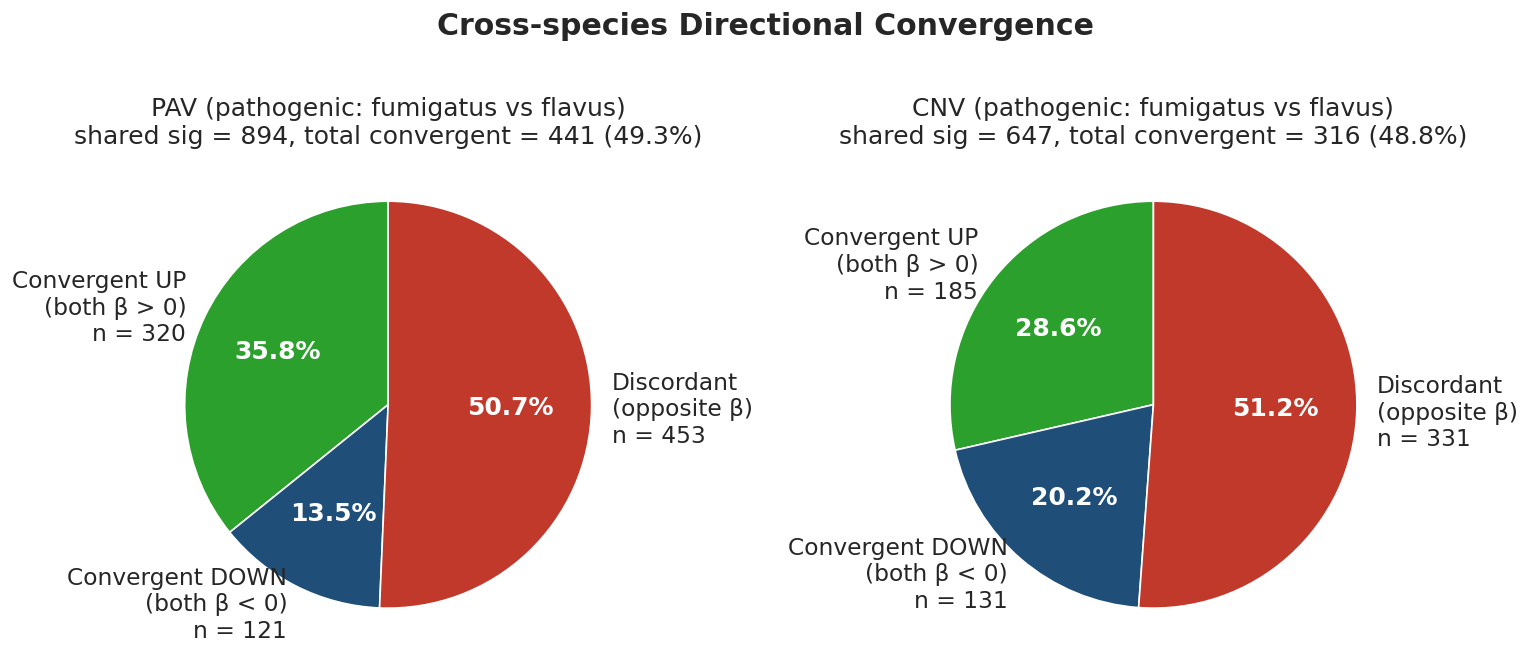

Saved -> /datadrive/Analysis/NB3_Results/convergence_summary_combined.png  (+ .pdf)


In [63]:
# --- Convergence as pie charts: UP/UP, DOWN/DOWN, DISCORDANT (NB3 add-on, v3) ---
# Uses the detailed per-OG convergence CSVs (β for both species) so
# CONVERGENT can be split into "both UP" and "both DOWN".
# --- Tweakable parameters ---
FS_CS = 15
DPI_CS = 400
FIG_W_PER_PIE_CS = 6.5
FIG_H_CS = 5.6

import sys
sys.path.insert(0, '/datadrive/Analysis')
import funpan_utils as fpu
NB3_RESULTS = Path('/datadrive/Analysis/NB3_Results')

_panels = [
    ('PAV (pathogenic: fumigatus vs flavus)',
     NB3_RESULTS / 'convergence' / 'pathogenic_functional_pav_convergence.csv'),
    ('CNV (pathogenic: fumigatus vs flavus)',
     NB3_RESULTS / 'convergence' / 'pathogenic_functional_cnv_convergence.csv'),
]
_panels = [(t, p) for t, p in _panels if p.exists()]
if not _panels:
    print('No per-OG convergence CSVs in NB3_Results/convergence/')
else:
    fig, axes = plt.subplots(1, len(_panels),
                             figsize=(FIG_W_PER_PIE_CS * len(_panels), FIG_H_CS),
                             squeeze=False)
    for ax, (title, path) in zip(axes.ravel(), _panels):
        df = pd.read_csv(path)
        sig = df[df['category'].isin(['CONVERGENT', 'DISCORDANT'])].copy()
        conv = sig[sig['category'] == 'CONVERGENT']
        disc = sig[sig['category'] == 'DISCORDANT']
        up_up   = ((conv['fumigatus_beta'] > 0) & (conv['flavus_beta'] > 0)).sum()
        dn_dn   = ((conv['fumigatus_beta'] < 0) & (conv['flavus_beta'] < 0)).sum()
        disc_n  = len(disc)
        n_total = up_up + dn_dn + disc_n
        sizes  = [up_up, dn_dn, disc_n]
        labels = [f'Convergent UP\n(both β > 0)\nn = {up_up:,}',
                  f'Convergent DOWN\n(both β < 0)\nn = {dn_dn:,}',
                  f'Discordant\n(opposite β)\nn = {disc_n:,}']
        colors = ['#2ca02c', '#1f4e79', '#c0392b']

        wedges, _txt, autotxts = ax.pie(
            sizes, labels=labels, colors=colors,
            autopct=lambda p: f'{p:.1f}%' if p >= 1 else '',
            startangle=90,
            wedgeprops=dict(linewidth=1.0, edgecolor='white'),
            textprops=dict(fontsize=FS_CS - 1,))# fontweight='bold'))
        for t in autotxts:
            t.set_color('white'); t.set_fontsize(FS_CS); t.set_fontweight('bold')

        pct_conv = 100 * (up_up + dn_dn) / max(n_total, 1)
        ax.set_title(
            f"{title}\n"
            f"shared sig = {n_total:,}, total convergent = "
            f"{up_up + dn_dn:,} ({pct_conv:.1f}%)",
            fontsize=FS_CS, pad=4)
        ax.set_aspect('equal')

    fig.suptitle('Cross-species Directional Convergence',
                 fontsize=FS_CS + 3, fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    out_png = NB3_RESULTS / 'convergence_summary_combined.png'
    out_pdf = NB3_RESULTS / 'convergence_summary_combined.pdf'
    fig.savefig(out_png, dpi=DPI_CS, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out_png}  (+ .pdf)')

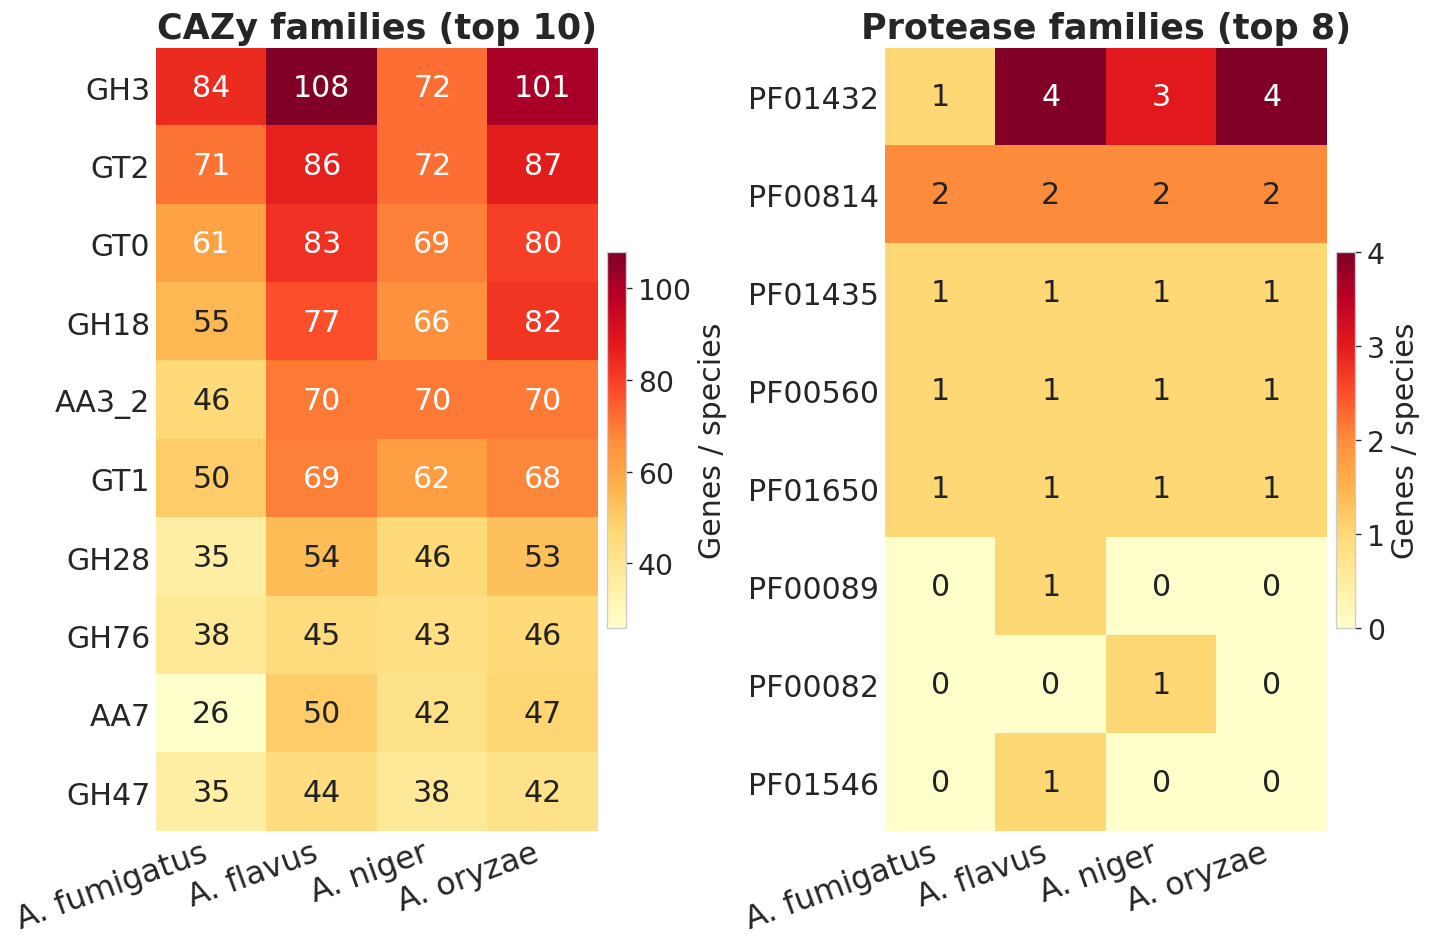

Saved -> /datadrive/Analysis/NB3_Results/family_comparison_combined.png  (+ .pdf)


In [58]:
# --- Combined: cross-species CAZy + protease family comparison (NB3 add-on, v2) ---
# Top 10 CAZy + top 10 protease (protease may yield fewer rows if <10 families).
# Heatmaps with no inner gridlines so they don't cut through the cell numbers.
# --- Tweakable parameters ---
FS_FAM = 20
DPI_FAM = 400
TOP_N_CAZY = 10
TOP_N_PROT = 10
FIG_W_FAM, FIG_H_FAM = 12.0, 8.0

import sys
sys.path.insert(0, '/datadrive/Analysis')
import funpan_utils as fpu
NB3_RESULTS = Path('/datadrive/Analysis/NB3_Results')
SPECIES = fpu.SPECIES_LIST

cazy_path = NB3_RESULTS / 'cazy_family_comparison.csv'
prot_path = NB3_RESULTS / 'protease_family_comparison.csv'
if not (cazy_path.exists() and prot_path.exists()):
    print('CAZy or protease comparison CSV missing.')
else:
    cazy = (pd.read_csv(cazy_path)
              .sort_values('total', ascending=False).head(TOP_N_CAZY))
    prot = (pd.read_csv(prot_path)
              .sort_values('total', ascending=False).head(TOP_N_PROT))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W_FAM, FIG_H_FAM))

    def _heat(ax, df, title):
        M = df[SPECIES].values
        im = ax.imshow(M, aspect='auto', cmap='YlOrRd')
        ax.set_xticks(np.arange(len(SPECIES)))
        ax.set_xticklabels([f"A. {s}" for s in SPECIES],
                           fontsize=FS_FAM - 1, rotation=20, ha='right')
        ax.set_yticks(np.arange(len(df)))
        ax.set_yticklabels(df['family'], fontsize=FS_FAM - 2)
        ax.set_title(title, fontsize=FS_FAM + 1, fontweight='bold')
        # Remove any inner gridlines / minor ticks that would slash through annotations
        ax.grid(False)
        ax.tick_params(which='both', length=0)
        ax.set_xticks(np.arange(M.shape[1] + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(M.shape[0] + 1) - 0.5, minor=True)
        ax.tick_params(which='minor', length=0)
        for spine in ('top', 'right', 'left', 'bottom'):
            ax.spines[spine].set_visible(False)
        vmax = M.max() if M.size else 1
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                v = M[i, j]
                ax.text(j, i, f'{int(v)}',
                        ha='center', va='center',
                        fontsize=FS_FAM - 2, #fontweight='bold',
                        color='white' if v > vmax * 0.55 else '#222')
        cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        cb.ax.tick_params(labelsize=FS_FAM - 3)
        cb.set_label('Genes / species', fontsize=FS_FAM - 2)
    _heat(ax1, cazy, f'CAZy families (top {len(cazy)})')
    _heat(ax2, prot, f'Protease families (top {len(prot)})')
    plt.tight_layout()
    out_png = NB3_RESULTS / 'family_comparison_combined.png'
    out_pdf = NB3_RESULTS / 'family_comparison_combined.pdf'
    fig.savefig(out_png, dpi=DPI_FAM, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out_png}  (+ .pdf)')

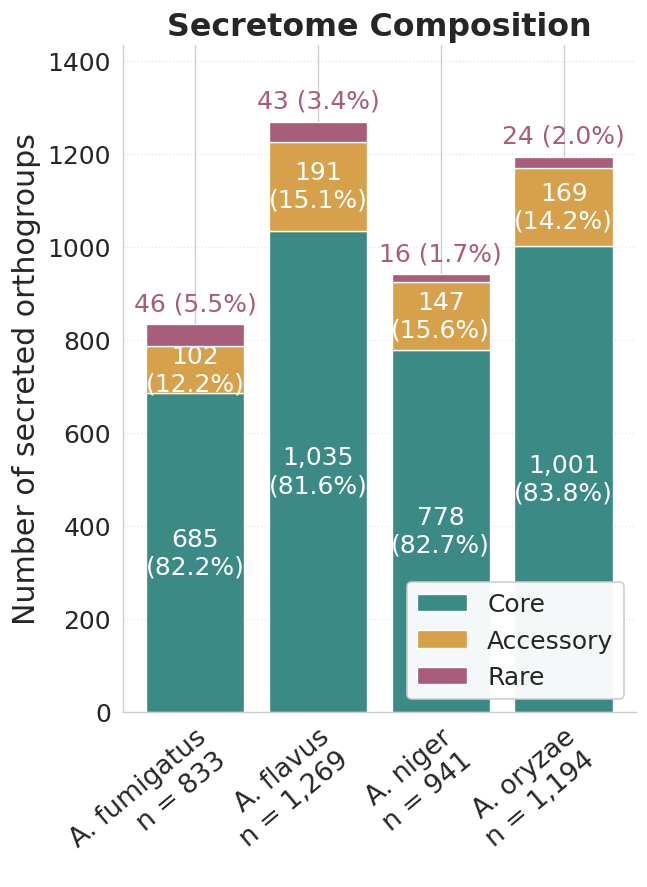

Saved -> /datadrive/Analysis/NB3_Results/secretome_combined.png  (+ .pdf)


In [64]:
# --- Secretome composition per species (vertical stacked bars) (NB3 v10) ---
# One vertical stacked bar per species (Core / Accessory / Rare). Uses a
# DISTINCT secretome palette (muted teal / sand / mauve) so it is not confused
# with the saturated green/orange/red used for the pangenome-composition plots.
# --- Tweakable parameters ---
FS_SEC = 18
DPI_SEC = 400
FIG_W_SEC, FIG_H_SEC = 5.5, 7.5
# Secretome palette: same Core>Accessory>Rare ordering, deliberately different
# shades from the pangenome-class colors (#2ca02c / #e67e22 / #c0392b).
CORE_C, ACC_C, RARE_C = '#3b8a86', '#d6a14a', '#a85d7a'

import sys
sys.path.insert(0, '/datadrive/Analysis')
import funpan_utils as fpu
NB3_RESULTS = Path('/datadrive/Analysis/NB3_Results')
SPECIES = fpu.SPECIES_LIST

_path = NB3_RESULTS / 'secretome_comparison.csv'
if not _path.exists():
    print(f'No secretome CSV at {_path}.')
else:
    sec = pd.read_csv(_path).set_index('species').reindex(SPECIES).reset_index()
    core_v = sec['n_secreted_in_Core'].values.astype(int)
    acc_v  = sec['n_secreted_in_Accessory'].values.astype(int)
    rare_v = sec['n_secreted_in_Rare'].values.astype(int)
    tot    = core_v + acc_v + rare_v

    x = np.arange(len(SPECIES))
    fig, ax = plt.subplots(figsize=(FIG_W_SEC, FIG_H_SEC))
    ax.bar(x, core_v, color=CORE_C, edgecolor='white', linewidth=0.8, label='Core')
    ax.bar(x, acc_v,  bottom=core_v, color=ACC_C, edgecolor='white', linewidth=0.8,
           label='Accessory')
    ax.bar(x, rare_v, bottom=core_v + acc_v, color=RARE_C, edgecolor='white',
           linewidth=0.8, label='Rare')

    ymax = tot.max()
    for i in range(len(SPECIES)):
        t = int(tot[i])
        # Inline labels for Core / Accessory (always wide enough vertically)
        for centre, val in [(core_v[i] / 2,             core_v[i]),
                            (core_v[i] + acc_v[i] / 2,  acc_v[i])]:
            pct = 100 * val / t if t else 0
            ax.text(i, centre, f'{int(val):,}\n({pct:.1f}%)',
                    ha='center', va='center',
                    fontsize=FS_SEC - 3, color='white')
        # Rare segment is too thin to label inline -> count + percent above bar
        r = int(rare_v[i]); rpct = 100 * r / t if t else 0
        ax.text(i, t + ymax * 0.015, f'{r:,} ({rpct:.1f}%)',
                ha='center', va='bottom',
                fontsize=FS_SEC - 3, color=RARE_C)

    ax.set_xticks(x)
    ax.set_xticklabels([f"A. {s}\nn = {int(t):,}"
                        for s, t in zip(SPECIES, tot)],
                       fontsize=FS_SEC - 2,
                       rotation=40, ha='right', rotation_mode='anchor')
    ax.set_ylabel('Number of secreted orthogroups', fontsize=FS_SEC)
    ax.set_ylim(0, ymax * 1.13)
    ax.tick_params(axis='y', labelsize=FS_SEC - 3)
    ax.set_title('Secretome Composition',
                 fontsize=FS_SEC + 1, fontweight='bold')
    ax.legend(loc='lower right', fontsize=FS_SEC - 3, frameon=True, framealpha=0.95)
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    plt.tight_layout()

    out_png = NB3_RESULTS / 'secretome_combined.png'
    out_pdf = NB3_RESULTS / 'secretome_combined.pdf'
    fig.savefig(out_png, dpi=DPI_SEC, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out_png}  (+ .pdf)')


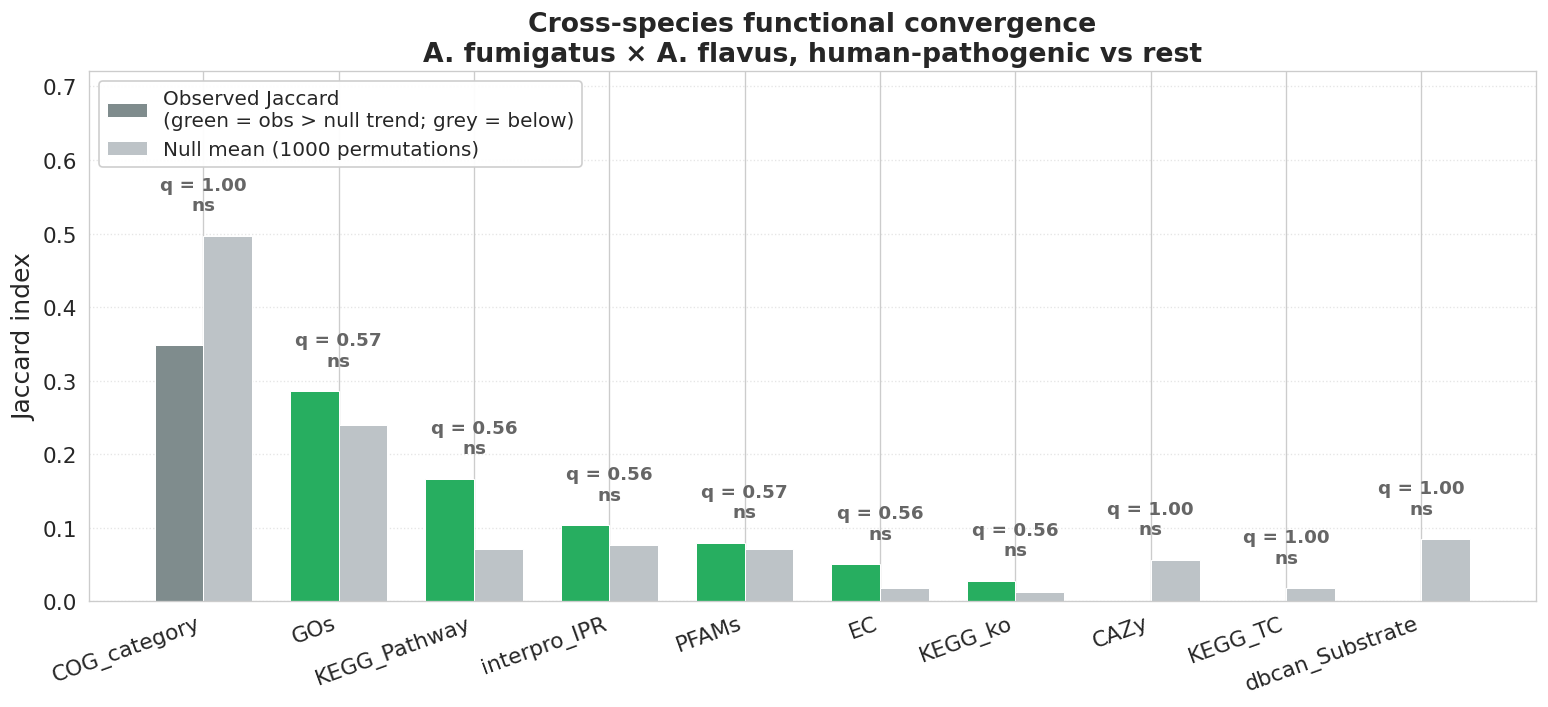

Saved -> /datadrive/Analysis/NB3_Results/functional_convergence_combined.png  (+ .pdf)


In [67]:
# --- Functional convergence: emphasising the NULL RESULT (NB3 add-on, v2) ---
# The biological result of this test is that NO annotation layer reaches
# significance (q < 0.05) for fumigatus x flavus human-pathogenic. The plot
# now makes that obvious:
#   - Observed vs null Jaccard side-by-side per layer.
#   - Each layer is annotated with its q-value coloured by significance
#     (red if q < 0.05, grey otherwise).
#   - A prominent corner callout reports "0 / N layers significant".
#   - Layers where observed > null are tinted darker to mark "trending
#     convergent but not significant" — easy to see there are a few.
# --- Tweakable parameters ---
FS_FC = 15
DPI_FC = 400
FIG_W_FC, FIG_H_FC = 13.0, 6.0
Q_THRESHOLD_FC = 0.05

import sys
sys.path.insert(0, '/datadrive/Analysis')
import funpan_utils as fpu
NB3_RESULTS = Path('/datadrive/Analysis/NB3_Results')

_path = NB3_RESULTS / 'functional_convergence_results_FILTERED.csv'
if not _path.exists():
    print(f'No functional convergence results at {_path}.')
else:
    fc = pd.read_csv(_path)
    # Sort by observed jaccard so the visually strongest layers go first
    fc = fc.sort_values('observed_jaccard', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(FIG_W_FC, FIG_H_FC))
    x = np.arange(len(fc))
    w = 0.36

    # Color the observed bars by whether obs > null (trending convergent) or not
    obs_colors = ['#27ae60' if o > n else '#7f8c8d'
                  for o, n in zip(fc['observed_jaccard'], fc['null_mean_jaccard'])]
    ax.bar(x - w/2, fc['observed_jaccard'], width=w, color=obs_colors,
           edgecolor='white', linewidth=0.6,
           label='Observed Jaccard\n(green = obs > null trend; grey = below)')
    ax.bar(x + w/2, fc['null_mean_jaccard'], width=w, color='#bdc3c7',
           edgecolor='white', linewidth=0.6,
           label='Null mean (1000 permutations)')

    # Per-layer q-value annotation above the higher of the two bars
    y_room = max(fc[['observed_jaccard', 'null_mean_jaccard']].max().max() * 1.45, 0.1)
    for i, row in fc.iterrows():
        tip = max(row['observed_jaccard'], row['null_mean_jaccard'])
        sig = bool(row['significant'])
        q   = row['q_value']
        col = '#c0392b' if sig else '#666'
        marker = '★' if sig else 'ns'
        ax.text(i, tip + y_room * 0.04,
                f"q = {q:.2f}\n{marker}",
                ha='center', va='bottom',
                fontsize=FS_FC - 4, color=col, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(fc['layer'], rotation=20, ha='right',
                       fontsize=FS_FC - 2)
    ax.set_ylabel('Jaccard index', fontsize=FS_FC)
    ax.set_ylim(0, y_room)
    n_sig    = int(fc['significant'].sum())
    n_total  = len(fc)
    n_trend  = int((fc['observed_jaccard'] > fc['null_mean_jaccard']).sum())
    ax.set_title('Cross-species functional convergence\n'
                 'A. fumigatus × A. flavus, human-pathogenic vs rest',
                 fontsize=FS_FC + 1, fontweight='bold')

    # Big corner callout: the result
    #callout = (
    #    f'{n_sig} / {n_total} layers significant at FDR < {Q_THRESHOLD_FC}\n'
    #    f'{n_trend} / {n_total} layers trending convergent (obs > null) but ns'
    #)
    #ax.text(0.99, 0.98, callout, transform=ax.transAxes,
    #        ha='right', va='top',
    #        fontsize=FS_FC, fontweight='bold', color='#c0392b' if n_sig > 0 else '#222',
    #        bbox=dict(boxstyle='round,pad=0.5', fc='#fff5ee',
    #                  ec='#c0392b', linewidth=1.5))
    ax.legend(loc='upper left', fontsize=FS_FC - 3, frameon=True, framealpha=0.95)
    ax.tick_params(axis='y', labelsize=FS_FC - 2)
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    out_png = NB3_RESULTS / 'functional_convergence_combined.png'
    out_pdf = NB3_RESULTS / 'functional_convergence_combined.pdf'
    fig.savefig(out_png, dpi=DPI_FC, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out_png}  (+ .pdf)')